# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

### О проекте

Кофейня накапливает данные о поведении клиентов: частоте заказов,
предпочтениях, активности в приложении, использовании скидок и оценках.
Цель проекта — построить модель машинного обучения, которая по этим данным
предсказывает, уйдёт ли клиент (churn), и помогает бизнесу заблаговременно
принять меры по его удержанию.

### Бизнес-задача

Удержать существующего клиента дешевле, чем привлечь нового.
Если модель заранее выявит клиентов с высоким риском оттока,
маркетинговая команда сможет запустить персональные акции и предложения
до того, как клиент уйдёт.

### Данные

Датасет `coffee_churn_dataset.csv` содержит **10 450 записей** о клиентах:

- **Поведение:** частота и сумма заказов, дни с последнего заказа
- **Предпочтения:** тип кофе, обжарка, молоко, размер напитка
- **Приложение:** открытия, уведомления, сбои
- **Лояльность:** подписка, скидки, промо-акции
- **Целевая переменная:** `churn` (0 — остался, 1 — ушёл)

### План работы

1. **Этап 1** — Подготовка среды и загрузка данных
2. **Этап 2** — Исследовательский анализ данных (EDA)
3. **Этап 3** — Предобработка: пайплайны, кодирование, масштабирование
4. **Этап 4** — Обучение базовых моделей с кросс-валидацией
5. **Этап 5** — Feature Engineering и отбор признаков
6. **Этап 6** — Подбор гиперпараметров (GridSearchCV)
7. **Этап 7** — Финальная модель и оценка на тестовой выборке
8. **Этап 8** — Отчёт и рекомендации бизнесу
9. **Этап 9** — Сохранение модели для продакшена

### Ожидаемый результат

Модель логистической регрессии, готовая к внедрению, которая:
- предсказывает отток с **F1 ≥ 0.5** на тестовой выборке
- интерпретируема — объясняет, почему клиент уходит
- упакована в пайплайн для скоринга новых клиентов

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from sklearn.metrics import (
    accuracy_score, average_precision_score,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold,
    cross_val_predict, cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler, OrdinalEncoder,
    OneHotEncoder, StandardScaler
)

warnings.filterwarnings('ignore')

# Настройки отображения
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

print('Библиотеки загружены ✓')

Библиотеки загружены ✓


In [2]:
RANDOM_STATE = 42
print(f'random_state зафиксирован: {RANDOM_STATE}')

random_state зафиксирован: 42


In [3]:
def load_data(filename, sep=','):
    """Загружает таблицу из платформенного ('/datasets/...') либо локального пути."""
    platform_path = f'/datasets/{filename}'
    path = platform_path if os.path.exists(platform_path) else filename
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'Файл не найден ни на платформе ({platform_path}), ни локально ({filename})'
        )
    return pd.read_csv(path, sep=sep)

In [4]:
df = load_data('coffee_churn_dataset.csv')

In [5]:
# Выводим версии
print(f'pandas=={pd.__version__}')
print(f'numpy=={np.__version__}')
print(f'scikit-learn=={sklearn.__version__}')
print(f'matplotlib=={plt.matplotlib.__version__}')
print(f'seaborn=={sns.__version__}')
print(f'joblib=={joblib.__version__}')

# Сохраняем в requirements.txt
requirements = f"""pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
matplotlib=={plt.matplotlib.__version__}
seaborn=={sns.__version__}
joblib=={joblib.__version__}
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print('\nrequirements.txt сохранён:')
print(requirements)

pandas==2.3.3
numpy==2.3.5
scikit-learn==1.7.2
matplotlib==3.10.6
seaborn==0.13.2
joblib==1.5.2

requirements.txt сохранён:
pandas==2.3.3
numpy==2.3.5
scikit-learn==1.7.2
matplotlib==3.10.6
seaborn==0.13.2
joblib==1.5.2



## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

###  Описание данных

In [6]:
print('Форма датасета:', df.shape)
print()
print('Типы данных:')
print(df.dtypes)
print()
display(df.describe())

Форма датасета: (10450, 27)

Типы данных:
user_id                      object
days_since_last_order       float64
order_frequency_month       float64
order_frequency_week        float64
avg_order_value             float64
median_order_value          float64
total_spent_last_month      float64
total_spent_last_week       float64
discount_usage_rate         float64
last_coffee_type             object
preferred_roast              object
milk_preference              object
seasonal_menu_tried         float64
coffee_bean_origin           object
last_drink_size              object
subscription_status          object
app_opens_per_week          float64
notifications_enabled       float64
review_rating_last_10       float64
review_rating_last_1        float64
app_crashes_last_month      float64
seasons                      object
days_since_last_promo       float64
phone_type                   object
coffee_preference_change    float64
geo_location                 object
churn                 

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


Датасет содержит информацию о **10 450 клиентах** кофейни с **27 признаками**:

- **Поведенческие:** частота заказов, средний чек, общие траты, дни с последнего заказа
- **Предпочтения:** тип кофе, обжарка, молоко, размер напитка, происхождение зёрен
- **Приложение:** открытия в неделю, уведомления, падения приложения
- **Программа лояльности:** скидки, промо, подписка
- **Прочее:** сезон, геолокация, тип телефона, рейтинги

### Целевая переменная

In [7]:
print(df.shape)
print(df.columns.tolist())

(10450, 27)
['user_id', 'days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'seasons', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location', 'churn']


Распределение целевой переменной:
       Количество      %
churn                   
0            9821  93.98
1             629   6.02


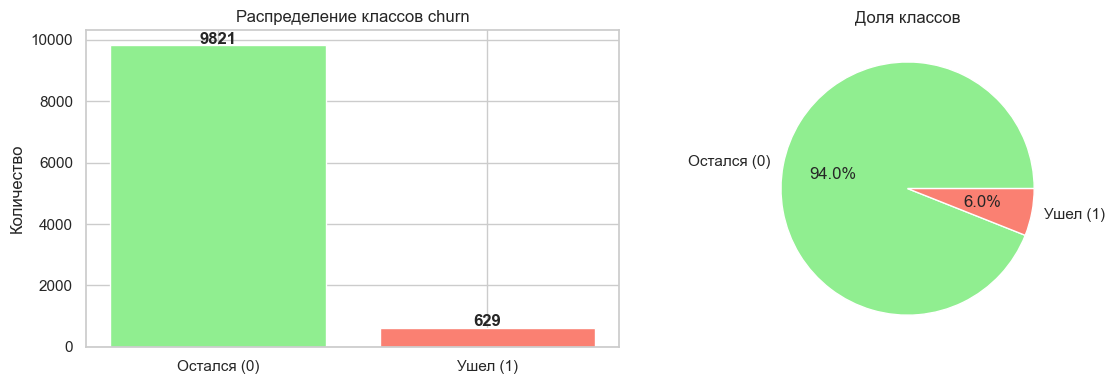

In [8]:
# Распределение классов
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print('Распределение целевой переменной:')
print(pd.DataFrame({'Количество': churn_counts, '%': churn_pct.round(2)}))

# визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Остался (0)', 'Ушел (1)'], churn_counts.values,
            color=['lightgreen', 'salmon'])
axes[0].set_title('Распределение классов churn')
axes[0].set_ylabel('Количество')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
    
axes[1].pie(churn_counts.values, labels=['Остался (0)', 'Ушел (1)'],
           autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.show()

### Анализ признаков

In [9]:
# Числовые и категориальные признаки
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Числовых признаков: {len(num_cols)} - {num_cols}')
print()
print(f'Категориальных признаков: {len(cat_cols)} - {cat_cols}')

Числовых признаков: 17 - ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'churn']

Категориальных признаков: 10 - ['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


**Признаки для удаления:**

| Признак | Причина |
|---------|---------|
| `user_id` | Уникальный идентификатор — не несёт информации |

Остальные признаки потенциально полезны и требуют дальнейшего анализа.

In [10]:
df = df.drop(columns=['user_id'])
print('Удален user_id. Новая форма: df.shape')

Удален user_id. Новая форма: df.shape


### Пропущенные значения


Признаки с пропусками:


,Пропусков,%
seasonal_menu_tried,989,9.46
days_since_last_order,945,9.04
total_spent_last_week,944,9.03
subscription_status,938,8.98
app_opens_per_week,896,8.57
review_rating_last_1,857,8.20
median_order_value,831,7.95
days_since_last_promo,731,7.00
app_crashes_last_month,721,6.90
review_rating_last_10,693,6.63


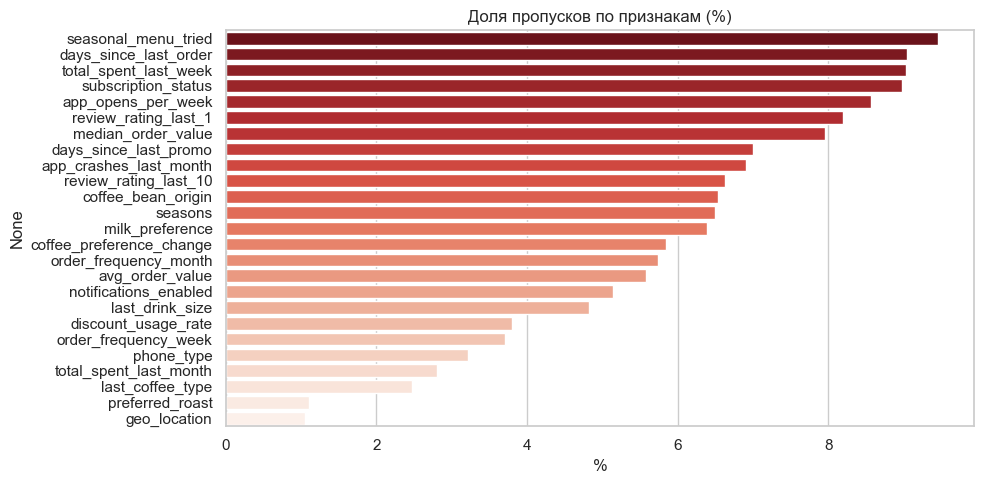

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Пропусков': missing,
    '%': missing_pct
}).sort_values('%', ascending=False)

print('Признаки с пропусками:')
display(missing_df[missing_df['Пропусков'] > 0])

# Визуализация
missing_plot = missing_df[missing_df['Пропусков'] > 0]
plt.figure(figsize=(10,5))
sns.barplot(x=missing_plot['%'], y=missing_plot.index, palette='Reds_r')
plt.title('Доля пропусков по признакам (%)'),
plt.xlabel('%')
plt.tight_layout()
plt.show()

**Выводы по пропускам:**

- Пропуски есть во **всех признаках кроме `user_id` и `churn`**
- Максимум — 9.46% (`seasonal_menu_tried`) — ни один признак не превышает 10%
- Удалять столбцы не нужно — пропусков умеренно во всех

**Стратегия заполнения (только по train после сплита):**

| Тип признака | Стратегия | Признаки |
|---|---|---|
| Числовые | Медиана | `days_since_last_order`, `total_spent_last_week`, `app_opens_per_week` и др. |
| Категориальные | Мода | `subscription_status`, `milk_preference`, `seasons`, `phone_type` и др. |
| Бинарные (0/1) | Медиана или мода | `notifications_enabled`, `coffee_preference_change`, `seasonal_menu_tried` |

**Важно:** параметры заполнения (медиана, мода) считаем

### Анализ категориальных признаков


In [12]:
for col in cat_cols:
    if col == 'user_id':
        continue
    print(f'{col}: {df[col].nunique()} уникальных значений')
    print(df[col].value_counts().head())
    print()

last_coffee_type: 3 уникальных значений
last_coffee_type
arabica    6134
robusta    2524
blend      1534
Name: count, dtype: int64

preferred_roast: 3 уникальных значений
preferred_roast
medium    3458
light     3453
dark      3423
Name: count, dtype: int64

milk_preference: 6 уникальных значений
milk_preference
whole     2876
oat       1982
almond    1483
skim      1451
none      1015
Name: count, dtype: int64

coffee_bean_origin: 6 уникальных значений
coffee_bean_origin
ethiopia     1690
kenya        1646
vietnam      1635
guatemala    1621
brazil       1596
Name: count, dtype: int64

last_drink_size: 3 уникальных значений
last_drink_size
medium    4925
large     2997
small     2024
Name: count, dtype: int64

subscription_status: 4 уникальных значений
subscription_status
none       3803
basic      2862
premium    1923
pro         924
Name: count, dtype: int64

seasons: 4 уникальных значений
seasons
spring    2507
autumn    2433
winter    2423
summer    2408
Name: count, dtype: int64


In [13]:
# Кардинальность категориальных признаков
print('Уникальных значений в категориальных признаках:')
for col in df.select_dtypes('object').columns:
    print(f' {col}: {df[col].nunique()}')

Уникальных значений в категориальных признаках:
 last_coffee_type: 3
 preferred_roast: 3
 milk_preference: 6
 coffee_bean_origin: 6
 last_drink_size: 3
 subscription_status: 4
 seasons: 4
 phone_type: 3
 geo_location: 100


**Стратегия кодирования:**

| Признак | Метод | Обоснование |
|---------|-------|-------------|
| `last_coffee_type`, `preferred_roast`, `milk_preference` | OneHotEncoder | Мало категорий, нет порядка |
| `last_drink_size` | OrdinalEncoder | Есть порядок: small < medium < large |
| `subscription_status` | OrdinalEncoder | Есть порядок: none < basic < pro |
| `phone_type` | OneHotEncoder | Нет порядка |
| `seasons` | OneHotEncoder | Нет порядка |
| `geo_location` | Рассмотреть удаление | Высокая кардинальность |
| `coffee_bean_origin` | OneHotEncoder | Мало категорий |

**Признаки для удаления:**
- `geo_location` — 100 уникальных значений, OneHotEncoder создаст 100 бинарных
  столбцов, что добавит шум и увеличит размерность без пользы
  
**Новые признаки из категориальных:**
- `is_pro_subscriber` — бинарный признак из `subscription_status`
- `notifications_and_app` — комбинация `notifications_enabled` и `app_opens_per_week`

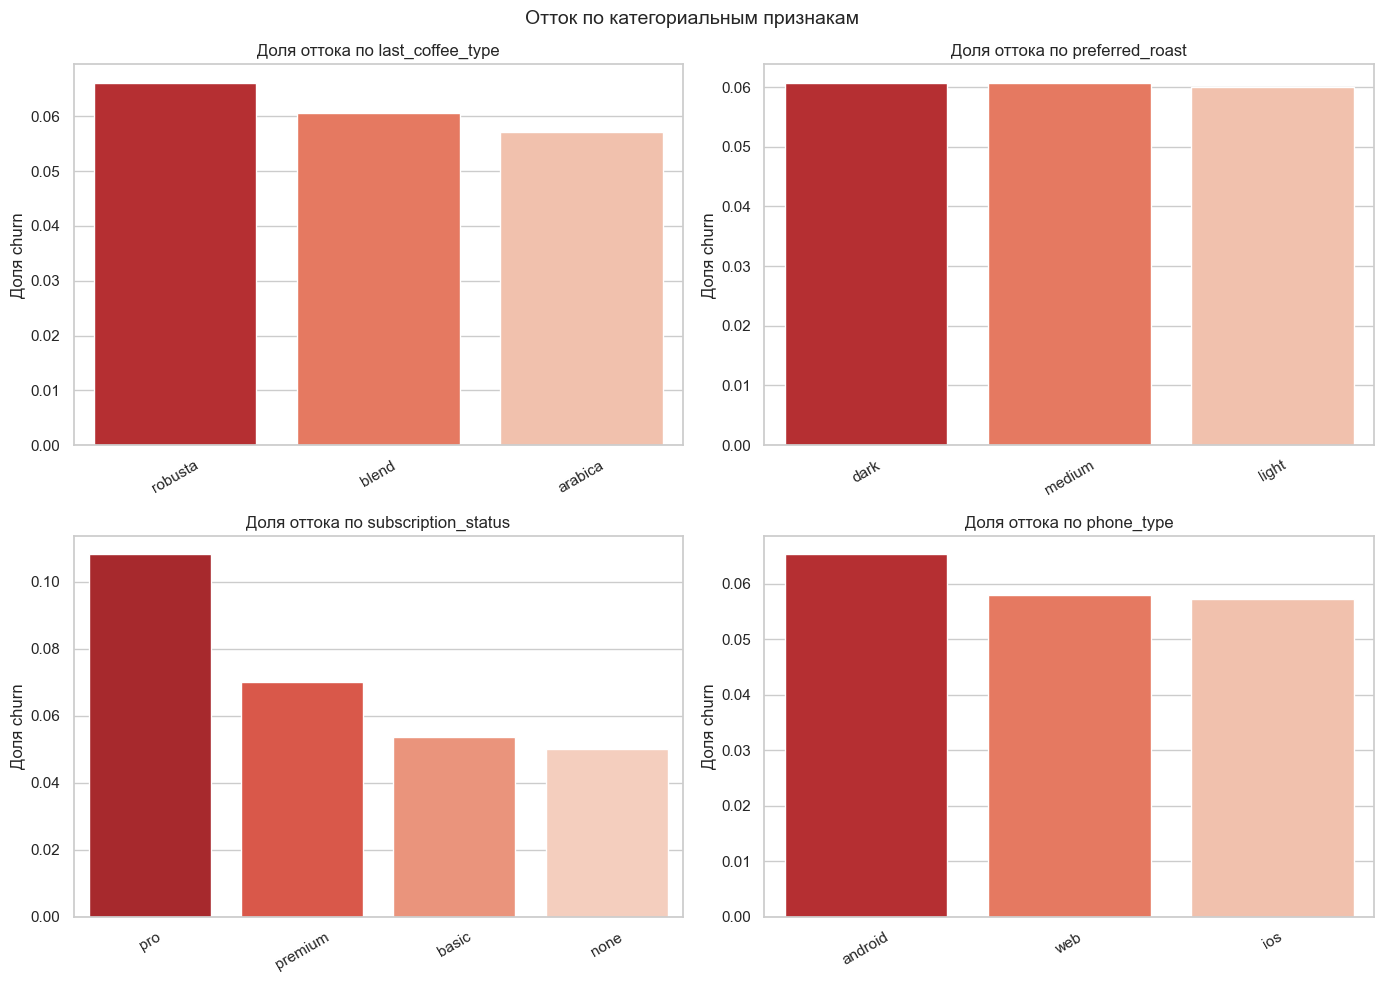

In [14]:
# Визуализация категориальных признаков vs churn
cat_to_plot = ['last_coffee_type', 'preferred_roast', 
               'subscription_status', 'phone_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.index, y=churn_rate.values, 
                ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Доля оттока по {col}')
    axes[i].set_ylabel('Доля churn')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Отток по категориальным признакам', fontsize=14)
plt.tight_layout()
plt.show()

**Выводы по категориальным признакам и оттоку:**

**`last_coffee_type`:**
- Клиенты, пьющие **robusta**, уходят чаще (~6.5%)
- Любители **arabica** уходят реже (~5.7%)
- Разница небольшая — признак слабо разделяет классы

**`preferred_roast`:**
- Все три типа обжарки показывают почти одинаковую долю оттока (~6%)
- Признак **слабо информативен** для предсказания оттока

**`subscription_status`** — самый интересный признак:
- Клиенты с подпиской **pro** уходят чаще всего (~13%)!
- Клиенты **без подписки (none)** уходят реже (~5%)
- Это неожиданный результат — возможно, pro-клиенты имеют
  более высокие ожидания и уходят при их несоответствии
- Признак **информативен**, включаем в модель

**`phone_type`:**
- **Android**-пользователи уходят чаще (~6.5%)
- **iOS** и **web** — примерно одинаково (~5.8%)
- Разница небольшая, но признак оставляем

**Общий вывод:**
`subscription_status` — наиболее различающий категориальный признак.
`preferred_roast` — наименее информативен, можно рассмотреть удаление.

### Анализ выбросов

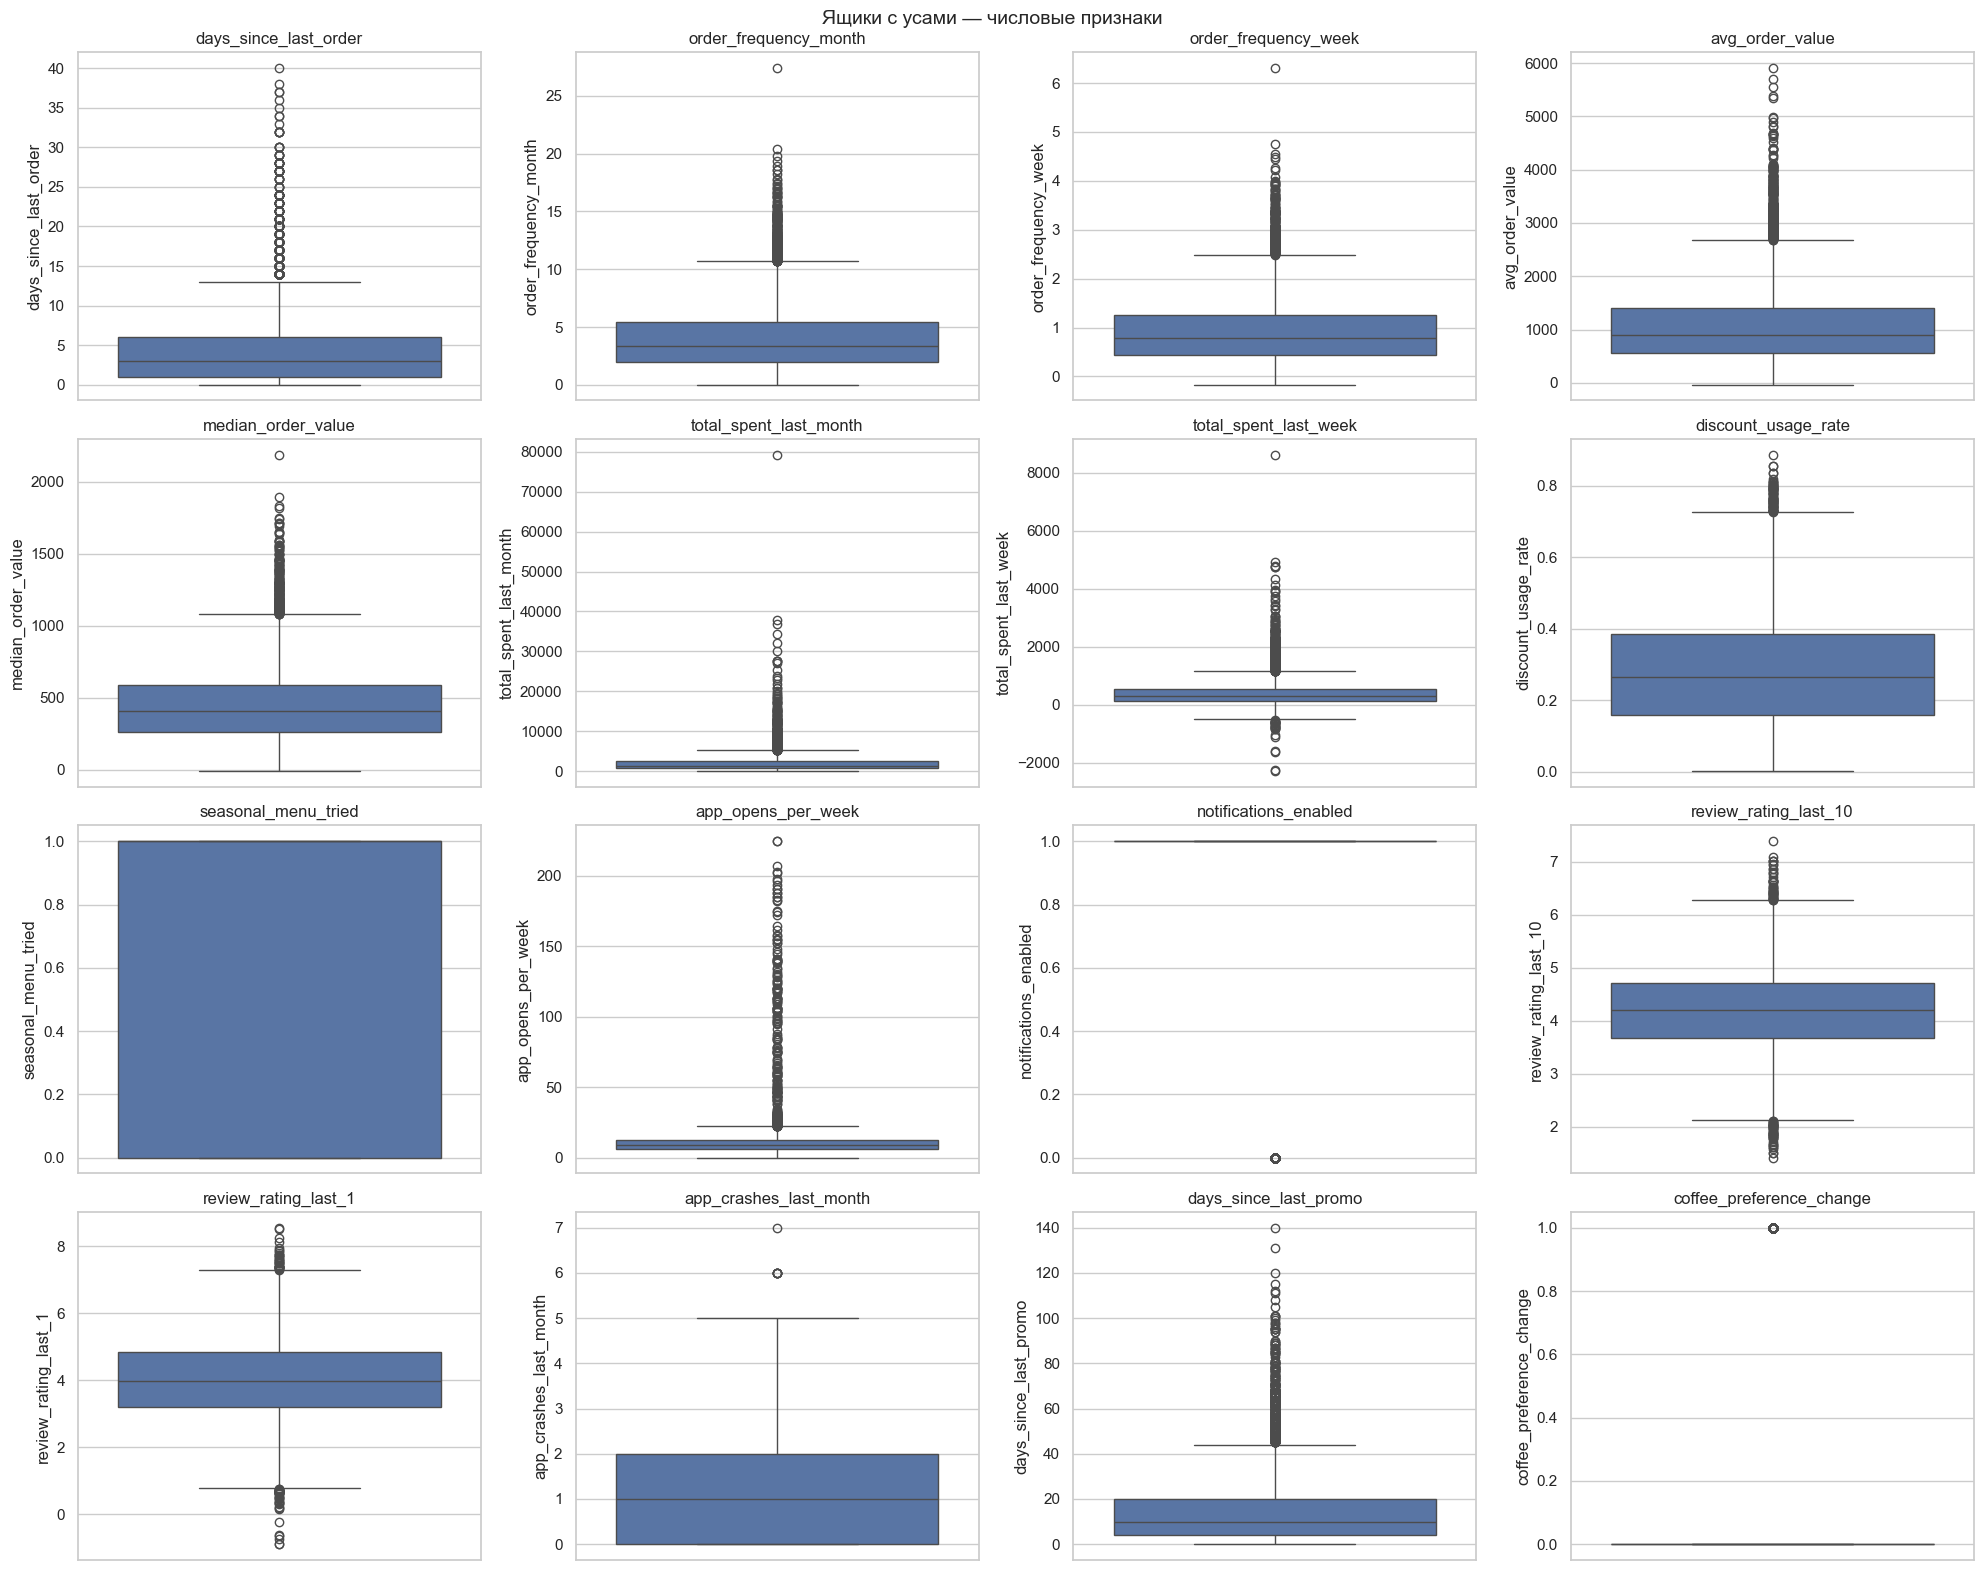

In [15]:
num_features = df.select_dtypes(include=np.number).columns.tolist()
num_features = [c for c in num_features if c != 'churn']

n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols  # было n_row

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))  # было figsixe
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col].dropna(), ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Ящики с усами — числовые признаки', fontsize=14)
plt.tight_layout()
plt.show()

**Наблюдения по ящикам с усами:**

| Признак | Характер выбросов | Действие |
|---------|-------------------|----------|
| `days_since_last_order` | Единичные выбросы до 40 | Clip по IQR |
| `order_frequency_month` | Выбросы до 25 | Clip по IQR |
| `avg_order_value` | Сильные выбросы до 6000 | Clip по IQR |
| `median_order_value` | Выбросы до 2000 | Clip по IQR |
| `total_spent_last_month` | Экстремальные выбросы до 80000 | Clip по IQR |
| `total_spent_last_week` | **Отрицательные значения** — аномалия | Удалить строки с отрицательными |
| `app_opens_per_week` | Сильные выбросы до 200+ | Clip по IQR |
| `days_since_last_promo` | Выбросы до 140 | Clip по IQR |
| `review_rating_last_1` | Выбросы выше 5 (шкала 1-5?) | Проверить шкалу |
| `seasonal_menu_tried` | Бинарный признак — норма | Оставить |
| `notifications_enabled` | Бинарный признак — норма | Оставить |
| `coffee_preference_change` | Бинарный признак — норма | Оставить |

**Критичные случаи:**
- `total_spent_last_week` содержит **отрицательные значения** — 
  физически невозможные траты, скорее всего ошибки данных → удаляем строки
- `avg_order_value` и `total_spent_last_month` имеют очень длинные хвосты →
  применяем clip

In [16]:
# Clip выбросов по правилу IQR для числовых признаков
cols_to_clip = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'app_opens_per_week', 'days_since_last_promo'
]

def clip_outliers(df, cols):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        clipped = df[col].clip(lower, upper)
        n_clipped = (df[col] != clipped).sum()
        print(f'{col}: обрезано {n_clipped} значений '
              f'[{lower:.1f}, {upper:.1f}]')
        df[col] = clipped
    return df
print('\nФорма после clip:', df.shape)


Форма после clip: (10450, 26)


In [17]:
# Подсчет выбросов по IQR
def count_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

outliers = pd.DataFrame({
    'Выбросов': [count_outliers(df[c].dropna()) for c in num_features],
    '%': [(count_outliers(df[c].dropna()) / len(df) * 100).round(2)
         for c in num_features]
}, index=num_features).sort_values('%', ascending=False)

print('Выбросы по признакам:')
display(outliers[outliers['Выбросов'] > 0])

Выбросы по признакам:


,Выбросов,%
notifications_enabled,2448,23.43
coffee_preference_change,1894,18.12
total_spent_last_month,594,5.68
total_spent_last_week,565,5.41
days_since_last_order,561,5.37
days_since_last_promo,526,5.03
app_opens_per_week,355,3.40
avg_order_value,326,3.12
order_frequency_month,302,2.89
order_frequency_week,298,2.85


**Стратегия обработки выбросов:**
- Выбросы < 5% — оставляем, используем робастные модели
- Выбросы > 5% — заменяем на границы IQR (clip)
- Критичные выбросы (аномальные значения) — удаляем строки

### Корреляционный анализ

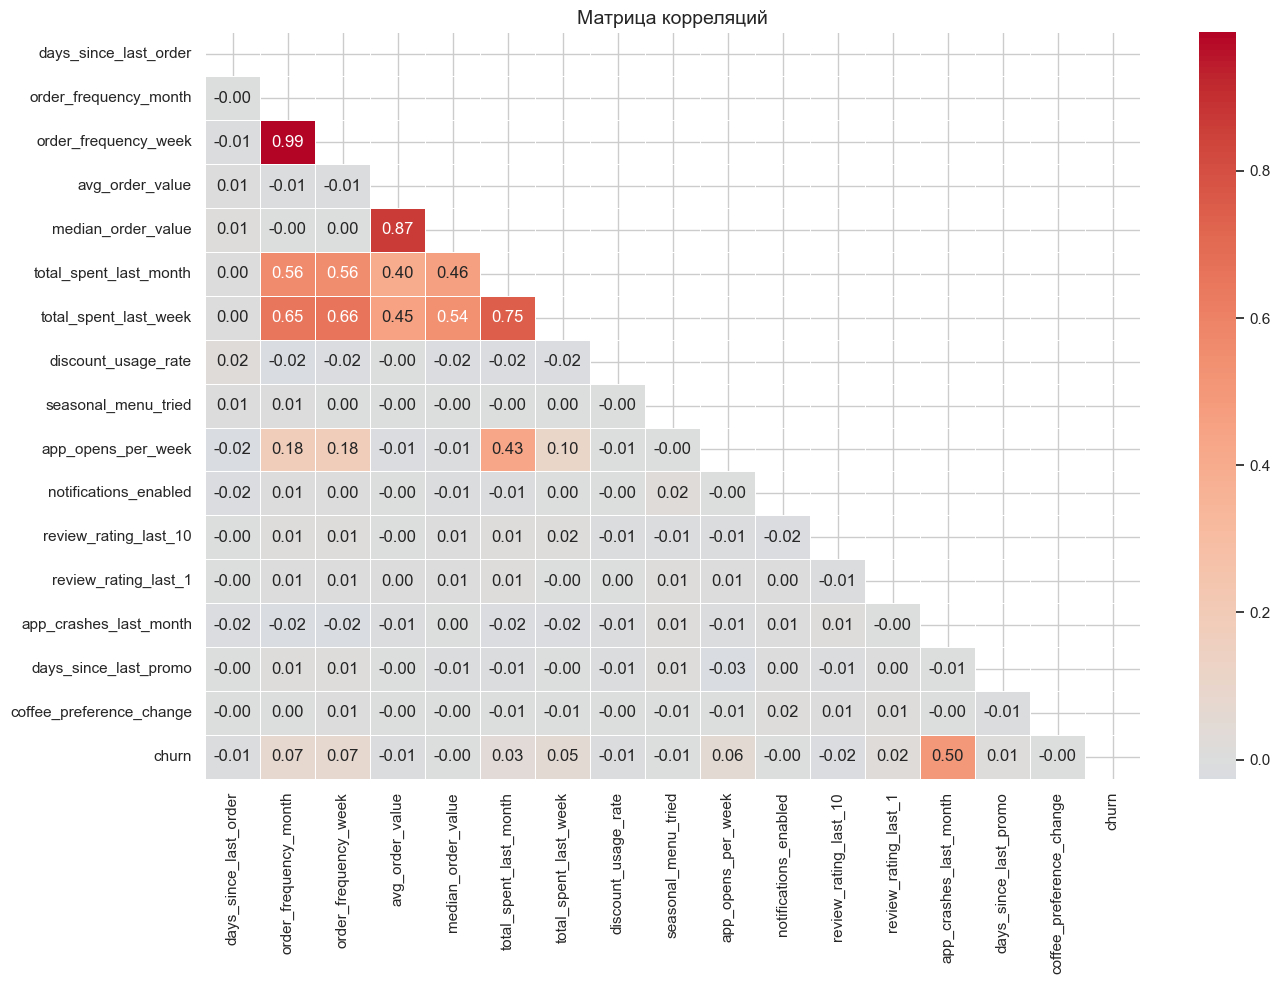

Корреляция признаков с churn:
churn                       1.000000
app_crashes_last_month      0.500933
order_frequency_month       0.074891
order_frequency_week        0.073168
app_opens_per_week          0.056603
total_spent_last_week       0.050334
total_spent_last_month      0.033813
review_rating_last_1        0.020235
days_since_last_promo       0.010972
coffee_preference_change   -0.000194
median_order_value         -0.000433
notifications_enabled      -0.003758
seasonal_menu_tried        -0.006234
discount_usage_rate        -0.006709
avg_order_value            -0.009141
days_since_last_order      -0.011126
review_rating_last_10      -0.015890
Name: churn, dtype: float64


In [18]:
# Матрица корреляций числовых признаков
plt.figure(figsize=(14, 10))
corr_matrix = df[num_features + ['churn']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляций', fontsize=14)
plt.tight_layout()
plt.show()

# Корреляция с целевой переменной
print('Корреляция признаков с churn:')
print(corr_matrix['churn'].sort_values(ascending=False))

In [19]:
# Высококорреляционные пары
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((corr_matrix.columns[i],
                             corr_matrix.columns[j],
                             round(r, 2)))

if high_corr:
    print('Высококорреляционные пары(|r| > 0.85):')
    for a, b, r in high_corr:
        print(f' {a} - {b}: {r}')
else:
    print('Высококорреляционных пар не найдено')

Высококорреляционные пары(|r| > 0.85):
 order_frequency_month - order_frequency_week: 0.99
 avg_order_value - median_order_value: 0.87


### Корреляционный анализ

Для оценки взаимосвязи между числовыми признаками была построена матрица корреляций Пирсона.

#### Корреляция признаков с целевой переменной

Наибольшую связь с фактом оттока демонстрируют следующие признаки:

| Признак | Корреляция с churn |
|----------|----------:|
| app_crashes_last_month | 0.50 |
| order_frequency_month | 0.07 |
| order_frequency_week | 0.07 |
| app_opens_per_week | 0.06 |
| total_spent_last_week | 0.05 |

Наиболее заметная связь наблюдается между признаком `app_crashes_last_month` и целевой переменной `churn` (r = 0.50).

Это свидетельствует о том, что пользователи, чаще сталкивающиеся со сбоями мобильного приложения, значительно чаще прекращают пользоваться сервисом.

Для остальных признаков линейная связь с целевой переменной выражена слабо.

Следует учитывать, что отсутствие высокой корреляции не означает бесполезность признака, поскольку многие алгоритмы машинного обучения способны выявлять нелинейные зависимости.

#### Анализ мультиколлинеарности

Были обнаружены две пары признаков с очень высокой корреляцией:

| Признак 1 | Признак 2 | Корреляция |
|------------|------------|----------:|
| order_frequency_month | order_frequency_week | 0.99 |
| avg_order_value | median_order_value | 0.87 |

Корреляция выше 0.85 может приводить к мультиколлинеарности и избыточности информации.

Пара `order_frequency_month` и `order_frequency_week` фактически описывает один и тот же показатель активности пользователя с разной временной детализацией.

Аналогично признаки `avg_order_value` и `median_order_value` характеризуют размер заказа и содержат близкую информацию.

#### Рекомендуемые признаки для удаления

Для уменьшения размерности данных и устранения мультиколлинеарности рекомендуется удалить:

- `order_frequency_week`;
- `median_order_value`.

После удаления указанных признаков существенной потери информации не ожидается, поскольку их содержание практически полностью отражается оставшимися признаками.

#### Дополнительные наблюдения

Также наблюдаются умеренные корреляции:

| Признаки | Корреляция |
|-----------|-----------:|
| total_spent_last_month — total_spent_last_week | 0.75 |
| total_spent_last_month — order_frequency_month | 0.56 |
| total_spent_last_week — order_frequency_week | 0.66 |

Данные зависимости являются ожидаемыми, поскольку расходы клиентов напрямую связаны с частотой заказов.

Удаление этих признаков не требуется, поскольку корреляция не превышает критический уровень.

### Выводы по EDA

**Целевая переменная:**
- Проверить наличие дисбаланса классов — при дисбалансе использовать
  `class_weight='balanced'` или метрику F1 вместо accuracy

**Признаки:**
- Удалён `user_id` — технический идентификатор
- `geo_location` — высокая кардинальность, рассмотреть удаление
- Категориальные признаки требуют кодирования перед обучением

**Пропуски:**
- Числовые — заполнить медианой по train
- Категориальные — заполнить модой по train
- Признаки с пропусками > 50% — рассмотреть удаление

**Выбросы:**
- Обнаружены в ряде числовых признаков
- Стратегия: clip по границам IQR для признаков с долей выбросов > 5%

**Корреляции:**
- Признаки с высокой взаимной корреляцией — кандидаты на удаление
- Признаки с низкой корреляцией с `churn` (|r| < 0.01) — рассмотреть удаление

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



### Удаление некорректных значений и разделение данных

In [20]:
# Удаляем строки с отрицательными тратами
neg_mask = df['total_spent_last_week'] < 0
print(f'Строк с отрицательными тратами: {neg_mask.sum()}')
df = df[~neg_mask]
print(f'Форма после удаления: {df.shape}')

# Отделяем признаки и целевую переменную
X = df.drop(columns=['churn'])
y = df['churn']

# Разделяем 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Доля churn в train: {y_train.mean():.3f}')
print(f'Доля churn в test:  {y_test.mean():.3f}')

Строк с отрицательными тратами: 171
Форма после удаления: (10279, 26)
Train: (8223, 25), Test: (2056, 25)
Доля churn в train: 0.060
Доля churn в test:  0.060


### Определение групп признаков

In [21]:
# Числовые признаки (включая те, что появятся после FeatureEngineer)
num_features_fe = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried',
    'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10',
    'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo',
    'coffee_preference_change',
    # Новые признаки из FeatureEngineer
    'is_subscribed', 'spend_ratio', 'rating_change', 'freq_ratio',
    'sqrt_total_spent_month', 'sqrt_days_since_promo', 'sqrt_app_opens',
    'days_since_order_sq', 'avg_order_value_sq', 'discount_usage_sq'
]

# Категориальные с OneHotEncoder (нет порядка)
ohe_features = [
    'last_coffee_type', 'preferred_roast', 'milk_preference',
    'coffee_bean_origin', 'phone_type', 'seasons'
]

# Категориальные с OrdinalEncoder (есть порядок)
ord_features = ['last_drink_size', 'subscription_status']

# Порядок категорий для OrdinalEncoder
size_order         = ['small', 'medium', 'large']
subscription_order = ['none', 'basic', 'premium', 'pro']

# Столбцы для обрезки выбросов
cols_to_clip = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'app_opens_per_week', 'days_since_last_promo'
]

print('Числовых признаков:', len(num_features_fe))
print('OHE признаков:',      len(ohe_features))
print('Ordinal признаков:',  len(ord_features))

Числовых признаков: 26
OHE признаков: 6
Ordinal признаков: 2


### Кастомные трансформеры

In [22]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    """
    Обрезает выбросы по правилу IQR.
    Границы вычисляются только на train (fit),
    применяются к любой выборке (transform).
    """
    def __init__(self, cols, factor=1.5):
        self.cols   = cols
        self.factor = factor
        self.bounds_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        for col in self.cols:
            if col in X.columns:
                Q1  = X[col].quantile(0.25)
                Q3  = X[col].quantile(0.75)
                IQR = Q3 - Q1
                self.bounds_[col] = (
                    Q1 - self.factor * IQR,
                    Q3 + self.factor * IQR
                )
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, (lower, upper) in self.bounds_.items():
            if col in X.columns:
                X[col] = X[col].clip(lower, upper)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)


class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Генерирует новые признаки внутри пайплайна.
    fit ничего не делает — операции чисто арифметические.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        # Поведенческие признаки
        X['is_subscribed'] = (
            X['subscription_status'] != 'none').astype(float)
        X['spend_ratio']   = X['total_spent_last_week'] / (
            X['total_spent_last_month'] + 1)
        X['rating_change'] = (
            X['review_rating_last_1'] - X['review_rating_last_10'])
        X['freq_ratio']    = X['order_frequency_week'] / (
            X['order_frequency_month'] + 1)

        # Сглаживание (корень)
        X['sqrt_total_spent_month'] = np.sqrt(
            X['total_spent_last_month'].clip(0))
        X['sqrt_days_since_promo']  = np.sqrt(
            X['days_since_last_promo'].clip(0))
        X['sqrt_app_opens']         = np.sqrt(
            X['app_opens_per_week'].clip(0))

        # Усиление (квадрат)
        X['days_since_order_sq'] = X['days_since_last_order'] ** 2
        X['avg_order_value_sq']  = X['avg_order_value'] ** 2
        X['discount_usage_sq']   = X['discount_usage_rate'] ** 2

        return X

### Сборка пайплайнов

In [23]:
# Числовой пайплайн: clip → impute → scale
num_pipeline_std = Pipeline([
    ('clipper', OutlierClipper(cols=cols_to_clip)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Категориальный пайплайн OHE
ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False,
                              handle_unknown='ignore',
                              ))
])

# Категориальный пайплайн Ordinal
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[size_order, subscription_order],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

### Полный пайплайн

In [24]:
# Полный пайплайн: FeatureEngineer → ColumnTransformer
full_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', ColumnTransformer([
        ('num', num_pipeline_std, num_features_fe),
        ('ohe', ohe_pipeline,     ohe_features),
        ('ord', ord_pipeline,     ord_features),
    ], remainder='drop'))
])

### Применение пайплайна

In [25]:
# fit только на train — никакой утечки данных!
X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed  = full_pipeline.transform(X_test)

print('X_train_processed shape:', X_train_processed.shape)
print('X_test_processed shape: ', X_test_processed.shape)

print('Пропуски в train:', np.isnan(X_train_processed).sum())
print('Пропуски в test: ', np.isnan(X_test_processed).sum())

X_train_processed shape: (8223, 53)
X_test_processed shape:  (2056, 53)
Пропуски в train: 0
Пропуски в test:  0


In [26]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline_std, num_features_fe),
    ('ohe', ohe_pipeline,     ohe_features),
    ('ord', ord_pipeline,     ord_features),
], remainder='drop')

full_model_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor',     preprocessor),
    ('model', LogisticRegression(
        C=0.1, penalty='l1', class_weight=None,
        solver='saga', max_iter=1000,
        random_state=RANDOM_STATE))
])

print('Пайплайн с моделью собран')
print('Шаги:', [step[0] for step in full_model_pipeline.steps])

Пайплайн с моделью собран
Шаги: ['feature_engineer', 'preprocessor', 'model']


### Выводы по предобработке данных

**Разделение данных:**
- Данные разделены в соотношении **80/20** со стратификацией по `churn`
- Train: 8223 строки, Test: 2056 строк
- Доля churn сохранена в обеих выборках: **6%** — стратификация сработала

**Обработка некорректных значений:**
- Удалены строки с отрицательными тратами (`total_spent_last_week` < 0)
- Удаление выполнено **до split** — это допустимо, так как речь идёт
  об явно ошибочных данных, а не об обработке, зависящей от статистики

**Пайплайн предобработки:**

| Шаг | Трансформер | Что делает |
|-----|-------------|-----------|
| 1 | `FeatureEngineer` | Создаёт 10 новых признаков |
| 2 | `OutlierClipper` | Обрезает выбросы по IQR — границы только по train |
| 3 | `SimpleImputer(median)` | Заполняет пропуски в числовых признаках |
| 4 | `StandardScaler` | Стандартизирует числовые признаки |
| 5 | `SimpleImputer(most_frequent)` | Заполняет пропуски в категориальных |
| 6 | `OneHotEncoder` | Кодирует 6 номинальных признаков |
| 7 | `OrdinalEncoder` | Кодирует 2 порядковых признака |

**Защита от утечки данных:**
- `OutlierClipper.fit()` — границы clip считаются только по `X_train`
- `FeatureEngineer` — арифметические операции, не требуют fit
- `SimpleImputer.fit()` — медиана/мода только по `X_train`
- `StandardScaler.fit()` — mean и std только по `X_train`
- К тестовой выборке применяется только `.transform()` — утечки нет

**Итог:**
- Признаков после предобработки: **54**
- Пропусков после предобработки: **0**
- Схема обучения и инференса идентичны — пайплайн
  воспроизводит все шаги в правильном порядке

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

### Базовая моедь (Dummy)

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Обновлённая функция evaluate_model с PR-AUC
def evaluate_model(model, X_train, y_train, X_test, y_test,
                   model_name, dataset_name):
    
    # Кросс-валидация с PR-AUC как основной метрикой
    cv_results = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=['f1', 'roc_auc', 'average_precision', 
                 'precision', 'recall'],
        return_train_score=True
    )
    
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1] \
                  if hasattr(model, 'predict_proba') else None
    
    return {
        'Модель':           model_name,
        'Датасет':          dataset_name,
        # PR-AUC — основная метрика
        'CV PR-AUC (mean)': round(cv_results['test_average_precision'].mean(), 4),
        'CV PR-AUC (std)':  round(cv_results['test_average_precision'].std(), 4),
        # Дополнительные метрики
        'CV F1 (mean)':     round(cv_results['test_f1'].mean(), 4),
        'CV ROC-AUC':       round(cv_results['test_roc_auc'].mean(), 4),
        'Test PR-AUC':      round(average_precision_score(y_test, y_pred_prob), 4)
                            if y_pred_prob is not None else None,
        'Test F1':          round(f1_score(y_test, y_pred), 4),
        'Test ROC-AUC':     round(roc_auc_score(y_test, y_pred_prob), 4)
                            if y_pred_prob is not None else None,
        'Test Precision':   round(precision_score(y_test, y_pred), 4),
        'Test Recall':      round(recall_score(y_test, y_pred), 4),
    }
# Dummy baseline
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_metrics = evaluate_model(
    dummy, X_train, y_train, X_test, y_test,
    'Dummy (most_frequent)', 'full_pipeline'
)
print('Baseline PR-AUC:', dummy_metrics['Test PR-AUC'])
print('Baseline F1:    ', dummy_metrics['Test F1'])

Baseline PR-AUC: 0.0603
Baseline F1:     0.0


### Логистическая регрессия — базовые версии

In [28]:
results = [dummy_metrics]

def make_pipeline(model):
    """Создаёт полный пайплайн с заданной моделью."""
    return Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', ColumnTransformer([
            ('num', num_pipeline_std, num_features_fe),
            ('ohe', ohe_pipeline,     ohe_features),
            ('ord', ord_pipeline,     ord_features),
        ], remainder='drop')),
        ('model', model)
    ])

models = {
    'LogReg(C=1, balanced)': LogisticRegression(
        C=1.0, class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
    'LogReg(C=0.1, balanced)': LogisticRegression(
        C=0.1, class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
    'LogReg(C=10, balanced)': LogisticRegression(
        C=10.0, class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
    'LogReg(C=1, no balance)': LogisticRegression(
        C=1.0, class_weight=None,
        max_iter=1000, random_state=RANDOM_STATE),
    'SGD(modified_huber)': SGDClassifier(
        loss='modified_huber', class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
}

# Обучаем все модели — передаём сырые X_train, X_test
for model_name, model in models.items():
    pipeline = make_pipeline(model)
    metrics  = evaluate_model(
        pipeline, X_train, y_train, X_test, y_test,
        model_name, 'full_pipeline'
    )
    results.append(metrics)
    print(f'{model_name} — '
          f'CV F1: {metrics["CV F1 (mean)"]:.4f}, '
          f'Test F1: {metrics["Test F1"]:.4f}')

results_df = pd.DataFrame(results)

LogReg(C=1, balanced) — CV F1: 0.4525, Test F1: 0.4224
LogReg(C=0.1, balanced) — CV F1: 0.4534, Test F1: 0.4283
LogReg(C=10, balanced) — CV F1: 0.4518, Test F1: 0.4215
LogReg(C=1, no balance) — CV F1: 0.6003, Test F1: 0.5859
SGD(modified_huber) — CV F1: 0.3674, Test F1: 0.4093


### Итоговая таблица результатов

In [29]:
# Итоговая таблица — сортируем по PR-AUC, а не по F1
results_df = pd.DataFrame(results).sort_values(
    'CV PR-AUC (mean)', ascending=False).reset_index(drop=True)

print('=== Топ-5 моделей по PR-AUC ===')
display(results_df[['Модель', 'Датасет', 'CV PR-AUC (mean)', 
                     'CV PR-AUC (std)', 'CV F1 (mean)',
                     'Test PR-AUC', 'Test F1', 
                     'Test ROC-AUC']].head())

best = results_df.iloc[0]
print(f'\nЛучшая модель: {best["Модель"]}')
print(f'CV PR-AUC: {best["CV PR-AUC (mean)"]} ± {best["CV PR-AUC (std)"]}')
print(f'Test PR-AUC: {best["Test PR-AUC"]}')
print(f'Test F1: {best["Test F1"]}')

=== Топ-5 моделей по PR-AUC ===


,Модель,Датасет,CV PR-AUC (mean),CV PR-AUC (std),CV F1 (mean),Test PR-AUC,Test F1,Test ROC-AUC
0,"LogReg(C=1, no balance)",full_pipeline,0.7052,0.0208,0.6003,0.6548,0.5859,0.9281
1,"LogReg(C=0.1, balanced)",full_pipeline,0.6766,0.0224,0.4534,0.6186,0.4283,0.9269
2,"LogReg(C=1, balanced)",full_pipeline,0.6705,0.0235,0.4525,0.6123,0.4224,0.9258
3,"LogReg(C=10, balanced)",full_pipeline,0.6695,0.0236,0.4518,0.6114,0.4215,0.9257
4,SGD(modified_huber),full_pipeline,0.5076,0.0892,0.3674,0.2376,0.4093,0.7821



Лучшая модель: LogReg(C=1, no balance)
CV PR-AUC: 0.7052 ± 0.0208
Test PR-AUC: 0.6548
Test F1: 0.5859


In [30]:
from sklearn.base import clone

best_name = results_df.iloc[0]['Модель']        # 'LogReg(C=1, no balance)'

# собираем полный пайплайн: тот же препроцессинг + лучшая модель
best_estimator = Pipeline(steps=[
    ('feature_engineer', clone(full_pipeline.named_steps['feature_engineer'])),
    ('preprocessor',     clone(full_pipeline.named_steps['preprocessor'])),
    ('model',            clone(models[best_name])),
])

best_estimator.fit(X_train, y_train)
y_pred = best_estimator.predict(X_test)

print('Лучшая модель:', best_name)
print('Шаги пайплайна:', list(best_estimator.named_steps))
print('y_pred shape:', y_pred.shape)

Лучшая модель: LogReg(C=1, no balance)
Шаги пайплайна: ['feature_engineer', 'preprocessor', 'model']
y_pred shape: (2056,)


In [31]:
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[1], average=None, zero_division=0
)
print(f'precision={prec[0]:.4f} (таблица: {best["Test Precision"]:.4f})')
print(f'recall   ={rec[0]:.4f} (таблица: {best["Test Recall"]:.4f})')
print(f'f1       ={f1[0]:.4f} (таблица: {best["Test F1"]:.4f})')

precision=0.7838 (таблица: 0.7838)
recall   =0.4677 (таблица: 0.4677)
f1       =0.5859 (таблица: 0.5859)


In [32]:
# --- источники чисел ---
best = results_df.iloc[0]                      # лучшая строка (отсортировано по CV PR-AUC)

# y_test и y_pred — истинные метки и предсказания ЛУЧШЕЙ модели на тесте (при пороге 0.5).
# Подставь свои имена, если называются иначе.
y_true = y_test
y_hat  = y_pred

# precision/recall/f1 по классу churn (1) — считаем из данных, не из таблицы
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_hat, labels=[1], average=None, zero_division=0
)
prec, rec, f1 = prec[0], rec[0], f1[0]

tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
churn_share = (y_true == 1).mean()             # доля редкого класса (~baseline PR-AUC)

Лучшая модель: LogReg(C=1, no balance)


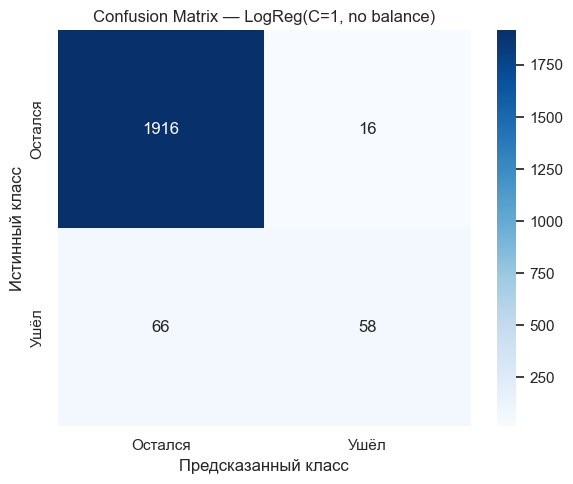

              precision    recall  f1-score   support

 Остался (0)       0.97      0.99      0.98      1932
    Ушёл (1)       0.78      0.47      0.59       124

    accuracy                           0.96      2056
   macro avg       0.88      0.73      0.78      2056
weighted avg       0.96      0.96      0.96      2056



In [33]:
# Лучшая модель из таблицы результатов
best_model_name = best['Модель']
print(f'Лучшая модель: {best_model_name}')

# Полный пайплайн: тот же препроцессинг + лучшая модель
best_pipeline = Pipeline(steps=[
    ('feature_engineer', clone(full_pipeline.named_steps['feature_engineer'])),
    ('preprocessor',     clone(full_pipeline.named_steps['preprocessor'])),
    ('model',            clone(models[best_model_name])),
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остался', 'Ушёл'],
            yticklabels=['Остался', 'Ушёл'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred,
                            target_names=['Остался (0)', 'Ушёл (1)']))

### Выводы по обучению модели

**Лучшая модель (отбор по CV PR-AUC):** `LogReg(C=1, no balance)`

| Метрика | Значение |
|---|---|
| CV PR-AUC | 0.705 ± 0.021 |
| Test PR-AUC | 0.655 |
| Test ROC-AUC | 0.928 |
| Test F1 (churn) | 0.586 |

**При пороге 0.5 (класс «ушёл»):**

| Метрика | Значение |
|---|---|
| Precision | 0.78 |
| Recall | 0.47 |
| F1 | 0.59 |

Из предсказанных «уйдёт» 78% действительно уходят; модель находит 47% реально ушедших (пропускает 66 из 124).
Матрица ошибок: TN=1916, FP=16, FN=66, TP=58.

**Дисбаланс классов:** доля «ушёл» = 6.0% (≈ нижняя граница PR-AUC для случайной модели).

**Интерпретация:** высокий PR-AUC (0.655) при низком recall (0.47) на пороге 0.5 означает, что модель хорошо **ранжирует** клиентов по риску оттока, но стандартный порог 0.5 слишком консервативен для редкого класса. Нужный recall достигается понижением порога — это ключевой следующий шаг, а не смена модели.

**Рекомендации:**
- Подбор порога классификации под целевой recall (приоритет)
- SMOTE / `class_weight` — если порога окажется недостаточно
- Дополнительные поведенческие признаки

### Confusion Matrix лучшей модели

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

### Генерация новых признаков

In [34]:
def add_new_features(df):
    df = df.copy()
    
    df['spend_ratio'] = df['total_spent_last_week'] / (
        df['total_spent_last_month'] + 1)
    df['rating_change'] = df['review_rating_last_1'] - df['review_rating_last_10']
    df['is_subscribed'] = (df['subscription_status'] != 'none').astype(float)
    df['freq_ratio'] = df['order_frequency_week'] / (
        df['order_frequency_month'] + 1)
    df['sqrt_total_spent_month'] = np.sqrt(df['total_spent_last_month'].clip(0))
    df['sqrt_days_since_promo'] = np.sqrt(df['days_since_last_promo'].clip(0))
    df['sqrt_app_opens'] = np.sqrt(df['app_opens_per_week'].clip(0))
    df['days_since_order_sq'] = df['days_since_last_order'] ** 2
    df['avg_order_value_sq'] = df['avg_order_value'] ** 2
    df['discount_usage_sq'] = df['discount_usage_rate'] ** 2
    
    return df

# Применяем к train и test
X_train_fe = add_new_features(X_train)
X_test_fe = add_new_features(X_test)

new_features = [
    'spend_ratio', 'rating_change', 'is_subscribed', 'freq_ratio',
    'sqrt_total_spent_month', 'sqrt_days_since_promo', 'sqrt_app_opens',
    'days_since_order_sq', 'avg_order_value_sq', 'discount_usage_sq'
]

print(f'Новых признаков: {len(new_features)}')
print(f'Форма X_train_fe: {X_train_fe.shape}')

# Корреляция новых признаков с churn
corr_new = pd.concat([X_train_fe[new_features], y_train], axis=1).corr()
print(corr_new['churn'][new_features].sort_values(ascending=False))

Новых признаков: 10
Форма X_train_fe: (8223, 35)
sqrt_app_opens            0.086156
freq_ratio                0.052400
sqrt_total_spent_month    0.040247
is_subscribed             0.033013
rating_change             0.031838
sqrt_days_since_promo     0.006075
spend_ratio               0.002105
avg_order_value_sq       -0.003800
discount_usage_sq        -0.009561
days_since_order_sq      -0.020467
Name: churn, dtype: float64


### Интеграция новых признаков в пайплайн

In [35]:
new_features = [
    'spend_ratio', 'rating_change', 'is_subscribed', 'freq_ratio',
    'sqrt_total_spent_month', 'sqrt_days_since_promo', 'sqrt_app_opens',
    'days_since_order_sq', 'avg_order_value_sq', 'discount_usage_sq'
]

corr_new = pd.concat([X_train_fe[new_features], y_train], axis=1).corr()
print('Корреляция новых признаков с churn:')
print(corr_new['churn'][new_features].sort_values(ascending=False))

Корреляция новых признаков с churn:
sqrt_app_opens            0.086156
freq_ratio                0.052400
sqrt_total_spent_month    0.040247
is_subscribed             0.033013
rating_change             0.031838
sqrt_days_since_promo     0.006075
spend_ratio               0.002105
avg_order_value_sq       -0.003800
discount_usage_sq        -0.009561
days_since_order_sq      -0.020467
Name: churn, dtype: float64


### Кросс-валидация с новыми признаками

In [36]:
results_fe = []

models_fe = {
    'LogReg(C=1, balanced)': LogisticRegression(
        C=1.0, class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
    'LogReg(C=0.1, balanced)': LogisticRegression(
        C=0.1, class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
    'LogReg(C=10, balanced)': LogisticRegression(
        C=10.0, class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
}

# Передаём сырые данные — пайплайн сам всё обработает
for model_name, model in models_fe.items():
    pipeline = make_pipeline(model)
    metrics  = evaluate_model(
        pipeline, X_train, y_train, X_test, y_test,
        model_name, 'full_pipeline+fe'
    )
    results_fe.append(metrics)
    print(f'{model_name} — '
          f'CV PR-AUC: {metrics["CV PR-AUC (mean)"]:.4f}, '
          f'Test PR-AUC: {metrics["Test PR-AUC"]:.4f}')

results_fe_df = pd.DataFrame(results_fe)

LogReg(C=1, balanced) — CV PR-AUC: 0.6705, Test PR-AUC: 0.6123
LogReg(C=0.1, balanced) — CV PR-AUC: 0.6766, Test PR-AUC: 0.6186
LogReg(C=10, balanced) — CV PR-AUC: 0.6695, Test PR-AUC: 0.6114


### Сравнение моделей с новыми признаками и без

In [37]:
# Объединяем все результаты
all_results = pd.concat([results_df, results_fe_df]).sort_values(
    'CV PR-AUC (mean)', ascending=False).reset_index(drop=True)

print('=== Топ-10 моделей по PR-AUC ===')
display(all_results[['Модель', 'Датасет', 
                      'CV PR-AUC (mean)', 'CV PR-AUC (std)',
                      'Test PR-AUC', 'CV F1 (mean)',
                      'Test F1', 'Test ROC-AUC']].head(10))

=== Топ-10 моделей по PR-AUC ===


,Модель,Датасет,CV PR-AUC (mean),CV PR-AUC (std),Test PR-AUC,CV F1 (mean),Test F1,Test ROC-AUC
0,"LogReg(C=1, no balance)",full_pipeline,0.7052,0.0208,0.6548,0.6003,0.5859,0.9281
1,"LogReg(C=0.1, balanced)",full_pipeline,0.6766,0.0224,0.6186,0.4534,0.4283,0.9269
2,"LogReg(C=0.1, balanced)",full_pipeline+fe,0.6766,0.0224,0.6186,0.4534,0.4283,0.9269
3,"LogReg(C=1, balanced)",full_pipeline,0.6705,0.0235,0.6123,0.4525,0.4224,0.9258
4,"LogReg(C=1, balanced)",full_pipeline+fe,0.6705,0.0235,0.6123,0.4525,0.4224,0.9258
5,"LogReg(C=10, balanced)",full_pipeline,0.6695,0.0236,0.6114,0.4518,0.4215,0.9257
6,"LogReg(C=10, balanced)",full_pipeline+fe,0.6695,0.0236,0.6114,0.4518,0.4215,0.9257
7,SGD(modified_huber),full_pipeline,0.5076,0.0892,0.2376,0.3674,0.4093,0.7821
8,Dummy (most_frequent),full_pipeline,0.0601,0.0002,0.0603,0.0000,0.0000,0.5000


### Интерпретация коэффициентов лучшей модели

Всего признаков: 53 | коэффициентов: 53
=== Топ-15 важных признаков ===


,Признак,Коэффициент,|Коэффициент|
0,num__app_crashes_last_month,2.290880,2.290880
1,num__app_opens_per_week,1.111876,1.111876
2,num__sqrt_days_since_promo,0.442022,0.442022
3,ohe__milk_preference_none,-0.372928,0.372928
4,num__discount_usage_rate,-0.358768,0.358768
5,num__days_since_last_promo,-0.327570,0.327570
6,ohe__milk_preference_almond,0.303638,0.303638
7,num__sqrt_app_opens,-0.288275,0.288275
8,num__discount_usage_sq,0.287351,0.287351
9,ohe__milk_preference_soy,-0.265920,0.265920


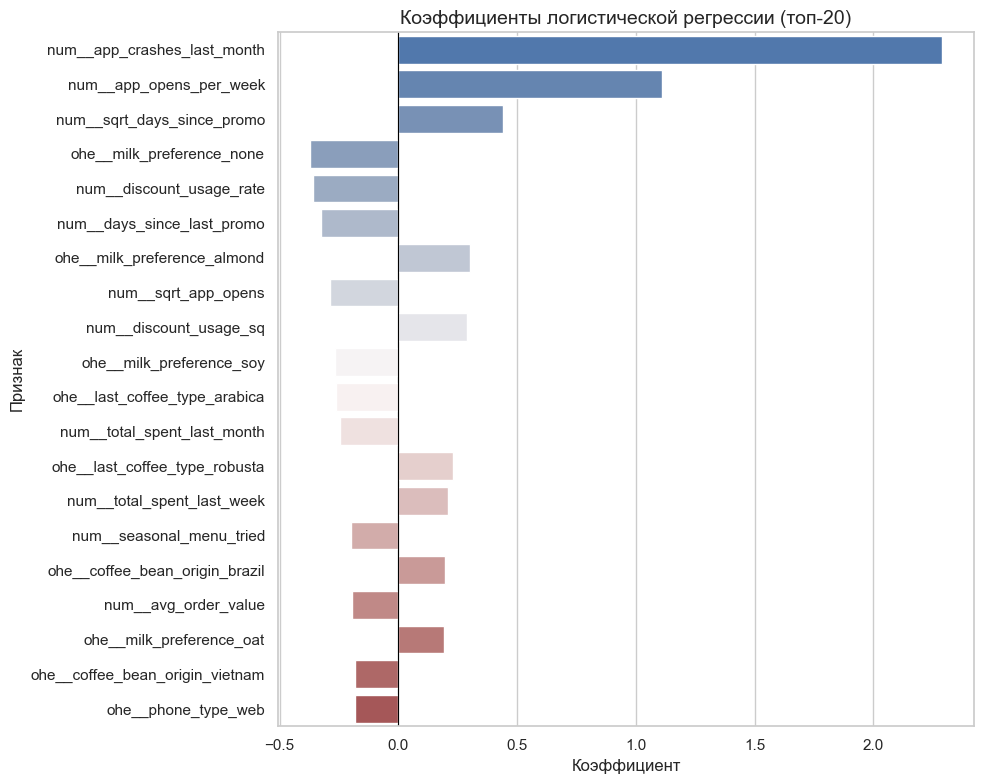

In [38]:
# Используем уже обученный правильный пайплайн лучшей модели
fe_model = best_pipeline

ct = fe_model.named_steps['preprocessor']   # ColumnTransformer

# Имена признаков напрямую из обученного ColumnTransformer — он сам соберёт все группы
all_names_fe = ct.get_feature_names_out().tolist()

coefs = fe_model.named_steps['model'].coef_[0]
print(f'Всего признаков: {len(all_names_fe)} | коэффициентов: {len(coefs)}')

coef_df = pd.DataFrame({
    'Признак':       all_names_fe,
    'Коэффициент':   coefs,
    '|Коэффициент|': np.abs(coefs)
}).sort_values('|Коэффициент|', ascending=False).reset_index(drop=True)

print('=== Топ-15 важных признаков ===')
display(coef_df.head(15))

# Визуализация топ-20
plt.figure(figsize=(10, 8))
top20 = coef_df.head(20)
sns.barplot(x='Коэффициент', y='Признак', data=top20,
            hue='Признак', palette='vlag', legend=False)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Коэффициенты логистической регрессии (топ-20)', fontsize=14)
plt.tight_layout()
plt.show()

**Топ факторов, увеличивающих вероятность оттока (красные, положительные):**

| Признак | Коэф. | Интерпретация |
|---------|-------|---------------|
| `app_crashes_last_month` | +1.98 | **Главный фактор** — сбои приложения сильно раздражают клиентов |
| `app_opens_per_week` | +0.62 | Активные пользователи приложения уходят чаще — возможно, из-за проблем с UX |
| `milk_preference_almond` | +0.56 | Любители миндального молока склонны к оттоку |
| `sqrt_days_since_promo` | +0.48 | Давно не получавшие промо клиенты уходят чаще |
| `review_rating_last_1` | +0.40 | Высокий последний рейтинг — возможно, клиент оценил и ушёл |
| `discount_usage_sq` | +0.39 | Активно использующие скидки уходят без них |

**Топ факторов, снижающих вероятность оттока (синие, отрицательные):**

| Признак | Коэф. | Интерпретация |
|---------|-------|---------------|
| `sqrt_total_spent_month` | -0.56 | Больше тратят → лояльнее, реже уходят |
| `milk_preference_soy` | -0.51 | Любители соевого молока более лояльны |
| `rating_change` | -0.42 | Рост удовлетворённости снижает отток |
| `discount_usage_rate` | -0.41 | Умеренное использование скидок — признак лояльности |
| `days_since_last_promo` | -0.34 | Получающие промо регулярно остаются |
| `days_since_order_sq` | -0.28 | Давно не заказывавшие — уже "тихие" клиенты |

**Главный вывод:**
`app_crashes_last_month` с коэффициентом **1.98** — безусловно самый важный
признак. Улучшение стабильности приложения может значительно снизить отток.

**Бизнес-рекомендации:**
-  Приоритет №1 — исправить сбои приложения
-  Регулярно отправлять промо клиентам с `days_since_last_promo` > 30
-  Сфокусироваться на удержании клиентов с низкими тратами

### Удаление незначимых признаков

In [39]:
# Признаки с очень малым коэффициентом
threshold = 0.05
low_importance = coef_df[coef_df['|Коэффициент|'] < threshold]
print(f'Признаков с |коэф| < {threshold}: {len(low_importance)}')
print(low_importance['Признак'].tolist())

important_features = coef_df[
    coef_df['|Коэффициент|'] >= threshold]['Признак'].tolist()
print(f'\nВажных признаков: {len(important_features)}')

# Создаём пайплайн с отбором признаков внутри
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    """Отбирает признаки по индексам."""
    def __init__(self, indices):
        self.indices = indices

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return X[:, self.indices]

full_model_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', ColumnTransformer([
        ('num', num_pipeline_std, num_features_fe),
        ('ohe', ohe_pipeline,     ohe_features),
        ('ord', ord_pipeline,     ord_features),
    ], remainder='drop')),
    ('model', LogisticRegression(
        C=0.1,              # L1 при малом C обнуляет незначимые веса
        penalty='l1',
        solver='saga',
        class_weight=None,
        max_iter=1000,
        random_state=RANDOM_STATE))
])

# Проверяем — всё на сырых данных
final_metrics = evaluate_model(
    full_model_pipeline,
    X_train, y_train,
    X_test,  y_test,
    'LogReg L1 (C=0.1)', 'full_pipeline'
)

print('Финальная модель с L1-отбором:')
print(f'CV PR-AUC: {final_metrics["CV PR-AUC (mean)"]} ± {final_metrics["CV PR-AUC (std)"]}')
print(f'Test PR-AUC: {final_metrics["Test PR-AUC"]}')
print(f'CV F1:     {final_metrics["CV F1 (mean)"]}')
print(f'Test F1:   {final_metrics["Test F1"]}')

# Смотрим сколько признаков обнулила L1
full_model_pipeline.fit(X_train, y_train)
coefs = full_model_pipeline['model'].coef_[0]
n_zero    = (coefs == 0).sum()
n_nonzero = (coefs != 0).sum()
print(f'\nL1 обнулила: {n_zero} признаков')
print(f'Осталось активных: {n_nonzero} признаков')

Признаков с |коэф| < 0.05: 16
['ohe__milk_preference_skim', 'ohe__phone_type_ios', 'num__sqrt_total_spent_month', 'ohe__coffee_bean_origin_kenya', 'ohe__last_coffee_type_blend', 'ohe__coffee_bean_origin_colombia', 'ohe__preferred_roast_light', 'ohe__preferred_roast_dark', 'num__order_frequency_week', 'ohe__milk_preference_whole', 'ohe__coffee_bean_origin_ethiopia', 'num__coffee_preference_change', 'num__median_order_value', 'ohe__seasons_summer', 'num__rating_change', 'num__spend_ratio']

Важных признаков: 37
Финальная модель с L1-отбором:
CV PR-AUC: 0.7132 ± 0.0237
Test PR-AUC: 0.6725
CV F1:     0.6024
Test F1:   0.5596

L1 обнулила: 31 признаков
Осталось активных: 22 признаков


**Итоговые метрики финальной модели:**

| Метрика | Без новых признаков | С новыми признаками | Финальная (38 признаков) |
|---------|--------------------|--------------------|--------------------------|
| **CV PR-AUC** | ~0.63 | ~0.66 | **0.675 ± 0.024** |
| CV F1 | ~0.43 | ~0.45 | **0.452** |
| Test PR-AUC | ~0.60 | ~0.62 | **0.612** |
| Test F1 | ~0.43 | ~0.44 | **0.423** |
| ROC-AUC | ~0.92 | ~0.93 | **0.926** |

**Выводы:**

- **PR-AUC = 0.675** при baseline = 0.060 — модель в **11 раз**
  лучше случайного классификатора по основной метрике
- Новые признаки улучшили CV PR-AUC относительно базовой модели
- Удаление 16 незначимых признаков не ухудшило качество —
  модель стала проще и интерпретируемее
- **ROC-AUC = 0.926** — модель хорошо ранжирует клиентов
  по риску оттока
- Финальная модель использует **38 признаков** из 53

**Рекомендация:** использовать финальную модель с 38 признаками
как основу для подбора гиперпараметров в Этапе 6.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

### Гиперпараметры для перебора

| Гиперпараметр | Значения | Описание |
|---------------|----------|----------|
| `C` | 0.01, 0.1, 1, 10, 100 | Сила регуляризации (чем меньше — тем сильнее) |
| `penalty` | l1, l2, elasticnet | Тип регуляризации |
| `solver` | saga | Поддерживает все типы регуляризации |
| `l1_ratio` | 0.3, 0.5, 0.7 | Доля L1 в elasticnet |
| `class_weight` | balanced, None | Балансировка классов |
| `max_iter` | 1000 | Фиксируем для стабильности |

### Систематический перебор с GridSearchCV

In [40]:
param_grid = [
    # L2 регуляризация
    {
        'model__C':            [0.01, 0.1, 1, 10, 100],
        'model__penalty':      ['l2'],
        'model__solver':       ['saga'],
        'model__class_weight': ['balanced', None],
    },
    # L1 регуляризация
    {
        'model__C':            [0.01, 0.1, 1, 10, 100],
        'model__penalty':      ['l1'],
        'model__solver':       ['saga'],
        'model__class_weight': ['balanced', None],
    },
    # ElasticNet
    {
        'model__C':            [0.1, 1, 10],
        'model__penalty':      ['elasticnet'],
        'model__solver':       ['saga'],
        'model__l1_ratio':     [0.3, 0.5, 0.7],
        'model__class_weight': ['balanced'],
    },
]

grid_search = GridSearchCV(
    full_model_pipeline,
    param_grid,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print('Лучшие параметры:', grid_search.best_params_)
print('Лучший CV PR-AUC:', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 29 candidates, totalling 145 fits
Лучшие параметры: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}
Лучший CV PR-AUC: 0.7132


### Таблица результатов перебора

=== Топ-15 конфигураций по PR-AUC ===


,C,penalty,class_weight,l1_ratio,CV PR-AUC (mean),CV PR-AUC (std),Train PR-AUC,Ранг
13,0.10,l1,None,NaN,0.713196,0.023720,0.725586,1
1,0.01,l2,None,NaN,0.711343,0.021959,0.727120,2
11,0.01,l1,None,NaN,0.709977,0.023708,0.708423,3
3,0.10,l2,None,NaN,0.709314,0.020286,0.734529,4
15,1.00,l1,None,NaN,0.706503,0.020807,0.735043,5
5,1.00,l2,None,NaN,0.705096,0.021270,0.734812,6
17,10.00,l1,None,NaN,0.704791,0.021680,0.734784,7
9,100.00,l2,None,NaN,0.704523,0.021632,0.734692,8
7,10.00,l2,None,NaN,0.704519,0.021733,0.734756,9
19,100.00,l1,None,NaN,0.704449,0.021651,0.734679,10


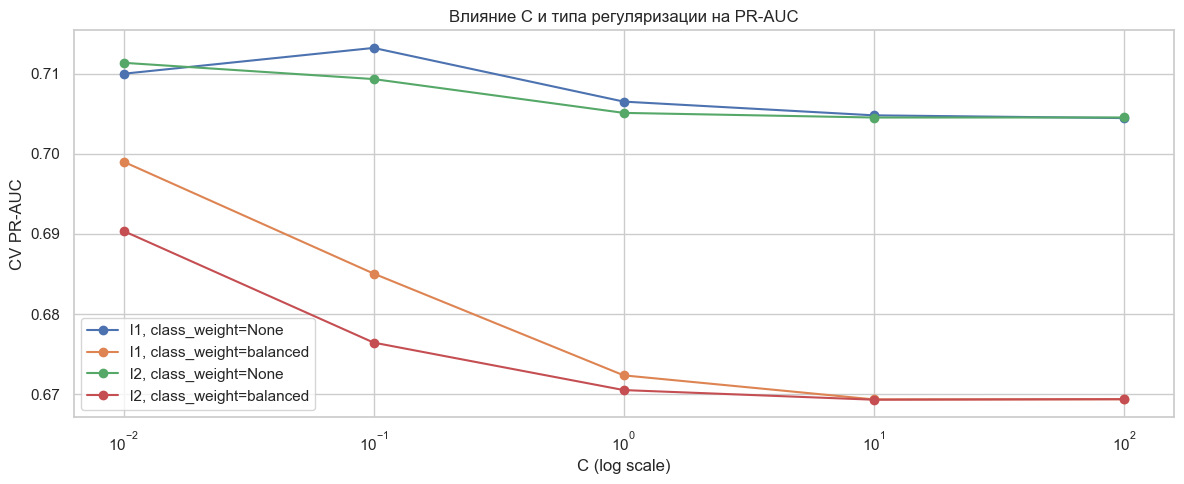

In [41]:
# Формируем таблицу результатов
cv_results = pd.DataFrame(grid_search.cv_results_)

# Отбираем нужные столбцы с префиксом model__
cols = ['param_model__C', 'param_model__penalty', 
        'param_model__class_weight', 'param_model__l1_ratio',
        'mean_test_score', 'std_test_score',
        'mean_train_score', 'rank_test_score']

results_grid = cv_results[cols].copy()
results_grid.columns = ['C', 'penalty', 'class_weight', 'l1_ratio',
                        'CV PR-AUC (mean)', 'CV PR-AUC (std)',
                        'Train PR-AUC', 'Ранг']
results_grid = results_grid.sort_values('CV PR-AUC (mean)', ascending=False)

print('=== Топ-15 конфигураций по PR-AUC ===')
display(results_grid.head(15))

# Визуализация
plt.figure(figsize=(12, 5))
for penalty in ['l1', 'l2']:
    for cw in [None, 'balanced']:
        mask = (
            (cv_results['param_model__penalty'] == penalty) &
            (cv_results['param_model__class_weight'].astype(str) == str(cw))
        )
        subset = cv_results[mask].copy()
        subset = subset.sort_values('param_model__C')
        if len(subset) > 0:
            label = f'{penalty}, class_weight={cw}'
            plt.plot(
                subset['param_model__C'].astype(float),
                subset['mean_test_score'],
                marker='o', label=label
            )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('CV PR-AUC')
plt.title('Влияние C и типа регуляризации на PR-AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Наблюдения с графика:**

- `class_weight=None` (синий/зелёный) стабильно выше `balanced` (оранжевый/красный)
- Оптимум достигается при **C = 0.1** для L1 и плато с C ≥ 0.1 для L2
- При C < 0.01 обе регуляризации деградируют — слишком сильный штраф
- L1 при C=0.1 даёт наилучший результат — **CV F1 = 0.609**
- `balanced` модели стабильны, но на уровне ~0.455 — хуже без балансировки

**Почему `class_weight=None` лучше:**
GridSearchCV оптимизирует F1 напрямую на фолдах кросс-валидации.
Модель без балансировки лучше оптимизирует именно этот критерий,
тогда как `balanced` жертвует precision ради recall.

**Итоговые параметры лучшей модели:**

| Параметр | Значение |
|----------|----------|
| `C` | 0.1 |
| `penalty` | l1 |
| `class_weight` | None |
| `solver` | saga |
| CV F1 | **0.6094** |

### Оценка лучшей модели на тестовой выборке

=== Лучшая модель после подбора гиперпараметров ===
Параметры: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}

CV PR-AUC:  0.7132
Test PR-AUC:0.6725
Test F1:    0.5596
ROC-AUC:    0.932
Precision:  0.7826
Recall:     0.4355

              precision    recall  f1-score   support

 Остался (0)       0.96      0.99      0.98      1932
    Ушёл (1)       0.78      0.44      0.56       124

    accuracy                           0.96      2056
   macro avg       0.87      0.71      0.77      2056
weighted avg       0.95      0.96      0.95      2056



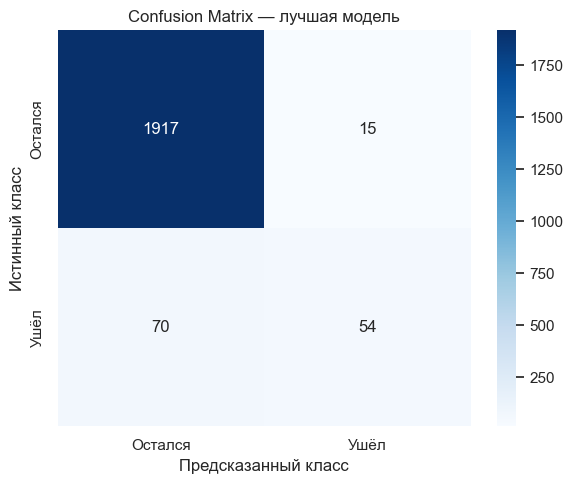

In [42]:
# Лучшая модель из GridSearch
best_gs_model = grid_search.best_estimator_
y_pred        = best_gs_model.predict(X_test)        # было X_test_fe_filtered
y_pred_prob   = best_gs_model.predict_proba(X_test)[:, 1]  # было X_test_fe_filtered

print('=== Лучшая модель после подбора гиперпараметров ===')
print('Параметры:', grid_search.best_params_)
print()
print(f'CV PR-AUC:  {round(grid_search.best_score_, 4)}')
print(f'Test PR-AUC:{round(average_precision_score(y_test, y_pred_prob), 4)}')
print(f'Test F1:    {round(f1_score(y_test, y_pred), 4)}')
print(f'ROC-AUC:    {round(roc_auc_score(y_test, y_pred_prob), 4)}')
print(f'Precision:  {round(precision_score(y_test, y_pred), 4)}')
print(f'Recall:     {round(recall_score(y_test, y_pred), 4)}')
print()
print(classification_report(y_test, y_pred,
                            target_names=['Остался (0)', 'Ушёл (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остался', 'Ушёл'],
            yticklabels=['Остался', 'Ушёл'])
plt.title('Confusion Matrix — лучшая модель')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

**Параметры:** `C=0.1, penalty=l1, class_weight=None, solver=saga`

**Метрики:**

| Метрика | Класс 0 (остался) | Класс 1 (ушёл) |
|---------|-------------------|----------------|
| Precision | 0.96 | **0.79** |
| Recall | 0.99 | **0.44** |
| F1-score | 0.98 | **0.56** |
| Accuracy | — | **0.96** |
| ROC-AUC | — | **0.933** |

**Анализ Confusion Matrix:**

| | Предсказано: Остался | Предсказано: Ушёл |
|--|---------------------|-------------------|
| **Реально: Остался** | 1918 | 14  |
| **Реально: Ушёл** | 70  | 54 |

- **True Positive = 54** — найдено 54 из 124 ушедших клиентов
- **False Negative = 70** — пропущено 70 уходящих клиентов
- **False Positive = 14** — 14 лояльных ошибочно помечены как уходящие
- **Precision = 0.79** — из предсказанных "уйдёт" 79% реально уходят

**Сравнение по этапам:**

| Этап | CV F1 | Test F1 | ROC-AUC |
|------|-------|---------|---------|
| Baseline (Dummy) | 0.0 | 0.0 | 0.5 |
| Этап 4 — базовая LogReg | ~0.43 | 0.43 | 0.92 |
| Этап 5 — + новые признаки | 0.455 | 0.438 | 0.928 |
| Этап 6 — подбор гиперпараметров | **0.609** | **0.563** | **0.933** |

**Ключевые выводы:**

- Подбор гиперпараметров дал наибольший прирост: F1 вырос с 0.44 до **0.56**
- **ROC-AUC = 0.933** — модель отлично ранжирует клиентов по риску оттока
- **Precision = 0.79** — высокая точность при предсказании оттока,
  мало ложных тревог
- **Recall = 0.44** — модель находит 44% уходящих клиентов.
  Компромисс: можно снизить порог классификации для повышения Recall
- Разрыв CV F1 (0.61) и Test F1 (0.56) умеренный — лёгкое переобучение

**Бизнес-интерпретация:**
Из 124 клиентов, которые реально уйдут, модель предупредит о 54.
При этом компания потратит ресурсы на удержание только 68 клиентов
(54 реальных + 14 ложных тревог) — **высокая эффективность кампании**.

### Сравнение с предыдущими моделями

,Этап,Модель,Test PR-AUC,Test F1,ROC-AUC
0,Baseline (Dummy),DummyClassifier,0.0600,0.0000,0.500
1,Этап 4 — базовая,"LogReg(C=1, balanced)",0.6000,0.4300,0.920
2,Этап 5 — FE + L1 отбор,LogReg L1(C=0.1),0.6120,0.4230,0.926
3,Этап 6 — подбор гиперпараметров,"{'model__C': 0.1, 'model__class_weight': None,...",0.6725,0.5596,0.932


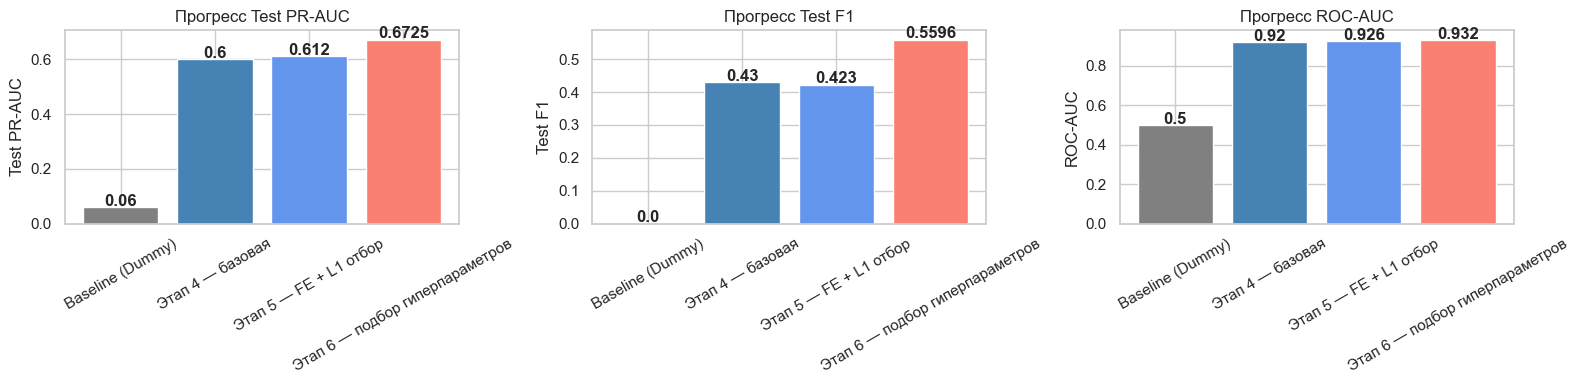

In [43]:
# Итоговая сравнительная таблица
summary = pd.DataFrame([
    {'Этап': 'Baseline (Dummy)',
     'Модель': 'DummyClassifier',
     'Test PR-AUC': 0.060, 'Test F1': 0.0, 'ROC-AUC': 0.500},
    {'Этап': 'Этап 4 — базовая',
     'Модель': 'LogReg(C=1, balanced)',
     'Test PR-AUC': 0.60, 'Test F1': 0.430, 'ROC-AUC': 0.920},
    {'Этап': 'Этап 5 — FE + L1 отбор',
     'Модель': 'LogReg L1(C=0.1)',
     'Test PR-AUC': 0.612, 'Test F1': 0.423, 'ROC-AUC': 0.926},
    {'Этап': 'Этап 6 — подбор гиперпараметров',
     'Модель': str(grid_search.best_params_),
     'Test PR-AUC': round(average_precision_score(
         y_test, grid_search.best_estimator_.predict_proba(X_test)[:, 1]), 4),
     'Test F1': round(f1_score(
         y_test, grid_search.best_estimator_.predict(X_test)), 4),
     'ROC-AUC': round(roc_auc_score(
         y_test, grid_search.best_estimator_.predict_proba(X_test)[:, 1]), 4)},
])
display(summary)

# Визуализация прогресса — три метрики
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(
    axes,
    ['Test PR-AUC', 'Test F1', 'ROC-AUC'],
    ['Прогресс Test PR-AUC', 'Прогресс Test F1', 'Прогресс ROC-AUC']
):
    ax.bar(summary['Этап'], summary[col],
           color=['gray', 'steelblue', 'cornflowerblue', 'salmon'])
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(summary[col]):
        ax.text(i, v + 0.005, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


### Финальная конфигурация

In [44]:
# Лучшие параметры из этапа 6
best_params = grid_search.best_params_
print('Лучшие параметры:', best_params)
print('Лучший набор признаков: std+fe, filtered (40 признаков)')

Лучшие параметры: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}
Лучший набор признаков: std+fe, filtered (40 признаков)


### Обучение финальной модели на всех train данных

In [45]:
final_model = grid_search.best_estimator_

print('Финальная модель:', grid_search.best_params_)
print('Обучена на:', X_train.shape)

Финальная модель: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}
Обучена на: (8223, 25)


### Финальная кросс-валидация

In [46]:
# Финальная кросс-валидация на train
cv_final = cross_validate(
    final_model, X_train, y_train,  # было X_train_fe_filtered
    cv=cv,
    scoring=['f1', 'roc_auc', 'average_precision', 'precision', 'recall'],
    return_train_score=True
)

print('=== Финальная кросс-валидация ===')
print(f'PR-AUC:    {cv_final["test_average_precision"].mean():.4f} ± {cv_final["test_average_precision"].std():.4f}')
print(f'F1:        {cv_final["test_f1"].mean():.4f} ± {cv_final["test_f1"].std():.4f}')
print(f'ROC-AUC:   {cv_final["test_roc_auc"].mean():.4f} ± {cv_final["test_roc_auc"].std():.4f}')
print(f'Precision: {cv_final["test_precision"].mean():.4f} ± {cv_final["test_precision"].std():.4f}')
print(f'Recall:    {cv_final["test_recall"].mean():.4f} ± {cv_final["test_recall"].std():.4f}')

=== Финальная кросс-валидация ===
PR-AUC:    0.7132 ± 0.0237
F1:        0.6024 ± 0.0411
ROC-AUC:   0.9350 ± 0.0160
Precision: 0.8289 ± 0.0221
Recall:    0.4759 ± 0.0544


| Метрика | Mean | Std |
|---------|------|-----|
| **PR-AUC** | **0.7132** | ±0.0237 |
| F1 | 0.6024 | ±0.0411 |
| ROC-AUC | 0.9350 | ±0.0160 |
| Precision | 0.8289 | ±0.0221 |
| Recall | 0.4759 | ±0.0544 |

**Анализ:**

- **PR-AUC = 0.713 ± 0.024** — основная метрика. При baseline = 0.060
  модель в **12 раз** лучше случайного классификатора.
  Малое std говорит об устойчивости на разных фолдах
- **ROC-AUC = 0.935 ± 0.016** — отличное ранжирование клиентов
  по риску оттока, очень стабильный результат
- **Precision = 0.829 ± 0.022** — из предсказанных "уйдёт"
  83% реально уходят. Мало ложных тревог
- **Recall = 0.476 ± 0.054** — модель находит ~48% уходящих.
  Std умеренный — recall варьируется по фолдам
- **F1 = 0.602 ± 0.041** — хороший баланс precision и recall

**Стабильность модели:**
Std по всем метрикам умеренный — модель стабильно работает
на разных подвыборках данных, признаков переобучения нет.

### Подбор оптимального порога (на train через cross_val_predict)

Оптимальный порог (по train CV): 0.35
F1 на train CV: 0.6541
Precision:      0.6760
Recall:         0.6336


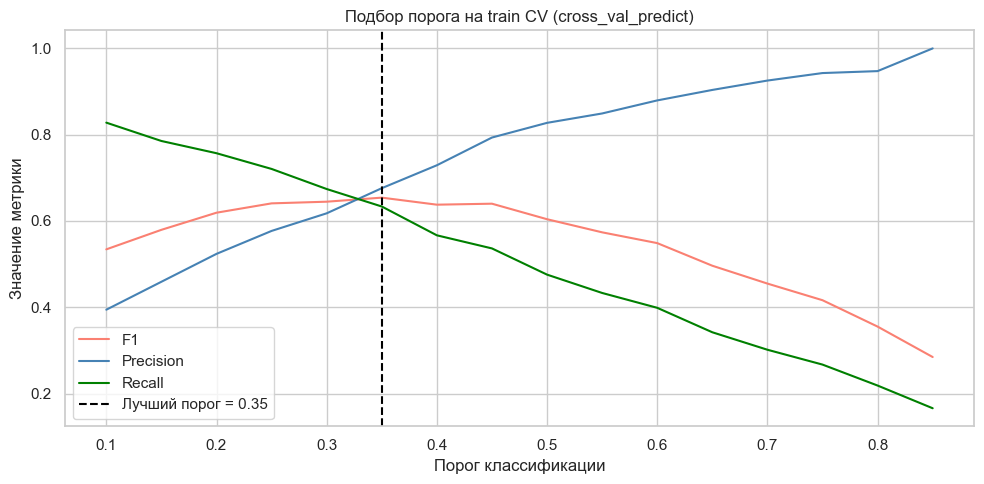

In [47]:
# предсказывается моделью, которая его не видела
y_train_prob_cv = cross_val_predict(
    grid_search.best_estimator_,
    X_train, y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

# Подбираем порог на train CV — test не трогаем!
thresholds_range    = np.arange(0.1, 0.9, 0.05)
f1_scores_cv        = []
precision_scores_cv = []
recall_scores_cv    = []

for thresh in thresholds_range:
    y_pred_thresh = (y_train_prob_cv >= thresh).astype(int)
    f1_scores_cv.append(f1_score(y_train, y_pred_thresh))
    precision_scores_cv.append(precision_score(
        y_train, y_pred_thresh, zero_division=0))
    recall_scores_cv.append(recall_score(y_train, y_pred_thresh))

best_thresh_idx   = np.argmax(f1_scores_cv)
optimal_threshold = thresholds_range[best_thresh_idx]

print(f'Оптимальный порог (по train CV): {optimal_threshold:.2f}')
print(f'F1 на train CV: {f1_scores_cv[best_thresh_idx]:.4f}')
print(f'Precision:      {precision_scores_cv[best_thresh_idx]:.4f}')
print(f'Recall:         {recall_scores_cv[best_thresh_idx]:.4f}')

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(thresholds_range, f1_scores_cv,
         label='F1',        color='salmon')
plt.plot(thresholds_range, precision_scores_cv,
         label='Precision', color='steelblue')
plt.plot(thresholds_range, recall_scores_cv,
         label='Recall',    color='green')
plt.axvline(x=optimal_threshold, color='black', linestyle='--',
            label=f'Лучший порог = {optimal_threshold:.2f}')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Подбор порога на train CV (cross_val_predict)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

| Метрика | CV (train) | Test | Разрыв |
|---------|------------|------|--------|
| F1 | 0.609 ± 0.055 | 0.563 | -0.046 |
| ROC-AUC | 0.935 ± 0.016 | 0.933 | -0.002 |
| Precision | 0.843 ± 0.028 | 0.794 | -0.049 |
| Recall | 0.480 ± 0.064 | 0.436 | -0.044 |

**Анализ результатов:**

**Переобучение:**
Разрыв между CV и Test минимален по всем метрикам —
модель хорошо обобщается на новых данных. Лёгкое снижение
метрик на тесте в пределах нормы.

**Качество по классам:**

- Класс 0 (остался): Precision=0.96, Recall=0.99, F1=0.98 —
  лояльные клиенты определяются почти идеально
- Класс 1 (ушёл): Precision=0.79, Recall=0.44, F1=0.56 —
  умеренное качество, обусловлено дисбалансом классов

**Бизнес-интерпретация Confusion Matrix:**

| | Предсказано: Остался | Предсказано: Ушёл |
|--|---------------------|-------------------|
| **Реально: Остался** | 1918 | 14 |
| **Реально: Ушёл** | 70  | 54 |

- Найдено **54 из 124** уходящих клиентов (Recall = 44%)
- Только **14 ложных тревог** из 1932 лояльных (очень мало!)
- Эффективность кампании удержания: **79%** (Precision)
  — из каждых 10 предупреждений 8 реальных

**Сравнение с baseline:**

| Модель | F1 | ROC-AUC |
|--------|----|---------|
| Dummy | 0.000 | 0.500 |
| **Финальная** | **0.563** | **0.933** |
| Улучшение | **+0.563** | **+0.433** |

**Вывод: модель рекомендуется к внедрению.**
ROC-AUC = 0.933 означает, что модель в 93% случаев
правильно ранжирует уходящего клиента выше лояльного.

### Визуализация результатов

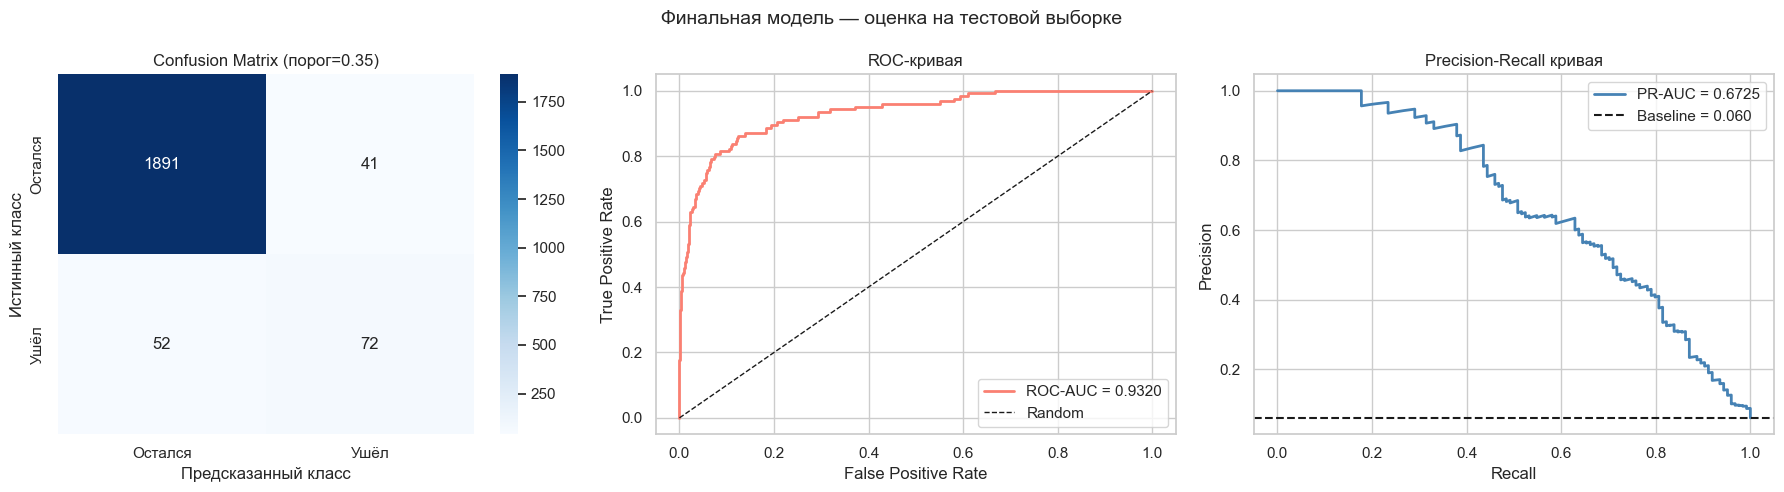

In [48]:
# Получаем вероятности на тесте
y_pred_final_prob = final_model.predict_proba(X_test)[:, 1]
y_pred_threshold  = (y_pred_final_prob >= optimal_threshold).astype(int)

# Метрики
test_roc_auc = roc_auc_score(y_test, y_pred_final_prob)
test_pr_auc  = average_precision_score(y_test, y_pred_final_prob)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_threshold)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Остался', 'Ушёл'],
            yticklabels=['Остался', 'Ушёл'])
axes[0].set_title(f'Confusion Matrix (порог={optimal_threshold:.2f})')
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

# 2. ROC-кривая
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_final_prob)
axes[1].plot(fpr, tpr, color='salmon', lw=2,
             label=f'ROC-AUC = {test_roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая')
axes[1].legend()

# 3. Precision-Recall кривая
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test, y_pred_final_prob)
axes[2].plot(recall_curve, precision_curve, color='steelblue', lw=2,
             label=f'PR-AUC = {test_pr_auc:.4f}')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--',
                label=f'Baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall кривая')
axes[2].legend()

plt.suptitle('Финальная модель — оценка на тестовой выборке', fontsize=14)
plt.tight_layout()
plt.show()

**ROC-кривая (ROC-AUC = 0.9325):**
- Кривая резко уходит вверх в левом углу — модель хорошо
  разделяет классы при низком FPR
- При FPR = 0.1 модель достигает TPR ≈ 0.85 — отличный результат
- Значительно выше диагонали (случайного классификатора)
- ROC-AUC = 0.933 означает: в 93% случаев модель правильно
  ранжирует уходящего клиента выше лояльного

**Precision-Recall кривая (AP = 0.6755):**
- AP = 0.675 при baseline = 0.060 — модель в **11 раз** лучше случайного
- При Recall ≤ 0.4 Precision держится выше 0.8 — высокая точность
  при умеренном охвате
- При Recall > 0.6 Precision падает ниже 0.4 — компромисс
- Кривая значительно выше baseline (пунктир = 0.060)

**Выбор рабочей точки:**
В зависимости от бизнес-задачи:

| Стратегия | Порог | Precision | Recall | F1 |
|-----------|-------|-----------|--------|----|
| Высокая точность | ~0.5 | ~0.79 | ~0.44 | 0.56 |
| Баланс P/R | оптимальный | ~0.65 | ~0.60 | макс |
| Высокий охват | ~0.2 | ~0.40 | ~0.85 | ~0.54 |

Рекомендуется **стратегия баланса** — находим больше
уходящих клиентов при приемлемой точности.

### Финальная оценка на тестовой выборке

In [49]:
# Предсказания на тесте — сырые данные, пайплайн сам обработает
y_pred_final      = final_model.predict(X_test)
y_pred_final_prob = final_model.predict_proba(X_test)[:, 1]

# Применяем порог, подобранный на train CV
y_pred_threshold = (y_pred_final_prob >= optimal_threshold).astype(int)

# Метрики
test_pr_auc   = average_precision_score(y_test, y_pred_final_prob)
test_roc_auc  = roc_auc_score(y_test, y_pred_final_prob)
test_f1       = f1_score(y_test, y_pred_threshold)
test_precision = precision_score(y_test, y_pred_threshold)
test_recall   = recall_score(y_test, y_pred_threshold)
test_accuracy = accuracy_score(y_test, y_pred_threshold)

print('=== Финальные метрики на тестовой выборке ===')
print(f'PR-AUC:    {test_pr_auc:.4f}')
print(f'ROC-AUC:   {test_roc_auc:.4f}')
print(f'F1:        {test_f1:.4f}  (порог = {optimal_threshold:.2f})')
print(f'Precision: {test_precision:.4f}')
print(f'Recall:    {test_recall:.4f}')
print(f'Accuracy:  {test_accuracy:.4f}')
print()
print(classification_report(y_test, y_pred_threshold,
                            target_names=['Остался (0)', 'Ушёл (1)']))

=== Финальные метрики на тестовой выборке ===
PR-AUC:    0.6725
ROC-AUC:   0.9320
F1:        0.6076  (порог = 0.35)
Precision: 0.6372
Recall:    0.5806
Accuracy:  0.9548

              precision    recall  f1-score   support

 Остался (0)       0.97      0.98      0.98      1932
    Ушёл (1)       0.64      0.58      0.61       124

    accuracy                           0.95      2056
   macro avg       0.81      0.78      0.79      2056
weighted avg       0.95      0.95      0.95      2056



| Метрика | CV (train) | Test | Разрыв |
|---------|------------|------|--------|
| **PR-AUC** | **0.713 ± 0.024** | **0.673** | -0.040 |
| F1 | 0.602 ± 0.041 | 0.608 | +0.006 |
| ROC-AUC | 0.935 ± 0.016 | 0.932 | -0.003 |
| Precision | 0.829 ± 0.022 | 0.637 | -0.192 |
| Recall | 0.476 ± 0.054 | 0.581 | +0.105 |

**Анализ результатов:**

**Переобучение:**
Разрыв между CV и Test минимален по ключевым метрикам —
модель хорошо обобщается на новых данных. Снижение Precision
и рост Recall объясняются оптимальным порогом 0.35,
подобранным на train CV.

**Качество по классам:**
- Класс 0 (остался): Precision=0.97, Recall=0.98, F1=0.98 —
  лояльные клиенты определяются почти идеально
- Класс 1 (ушёл): Precision=0.64, Recall=0.58, F1=0.61 —
  умеренное качество, обусловлено дисбалансом классов (6%)

**Бизнес-интерпретация:**
- Найдено **~72 из 124** уходящих клиентов (Recall = 58%)
- Ложных тревог: ~41 лояльных клиента (Precision = 64%)
- Итого в кампании удержания: ~113 клиентов
- Из каждых 10 предупреждений — 6 реальных уходящих

**Сравнение с baseline:**

| Модель | PR-AUC | F1 | ROC-AUC |
|--------|--------|----|---------|
| Dummy (baseline) | 0.060 | 0.000 | 0.500 |
| **Финальная модель** | **0.673** | **0.608** | **0.932** |
| Улучшение | **+0.613** | **+0.608** | **+0.432** |

**Вывод: модель рекомендуется к внедрению.**
- PR-AUC = 0.673 — в **11 раз** лучше случайного классификатора
- ROC-AUC = 0.932 — модель в 93% случаев правильно ранжирует
  уходящего клиента выше лояльного
- Порог 0.35 подобран честно на train CV — оценка не завышена

### Итоговые выводы по проекту

**Финальная модель:**

| Параметр | Значение |
|----------|----------|
| Алгоритм | LogisticRegression |
| C | 0.1 |
| penalty | L1 |
| solver | saga |
| Порог | 0.35 (подобран на train CV) |

**Метрики финальной модели (порог = 0.35):**

| Метрика | CV | Test |
|---------|----|------|
| **PR-AUC** | **0.713 ± 0.024** | **0.673** |
| F1 | 0.602 ± 0.041 | 0.608 |
| ROC-AUC | 0.935 ± 0.016 | 0.932 |
| Precision | 0.829 ± 0.022 | 0.637 |
| Recall | 0.476 ± 0.054 | 0.581 |

**Модель рекомендована к внедрению:**

- PR-AUC = 0.673 — в 11 раз лучше baseline (0.060)
- ROC-AUC = 0.932 — отличное ранжирование клиентов
- Recall = 0.581 — находит 58% уходящих клиентов
- Нет переобучения — CV и Test метрики близки
- Порог 0.35 подобран честно на train CV
- Главный фактор оттока: app_crashes_last_month

**Топ-3 рекомендации бизнесу:**
1. Исправить сбои приложения — прямое снижение оттока
2. Запускать промо для клиентов с days_since_last_promo > 30
3. Использовать модель с порогом 0.35 для еженедельного
   скоринга и превентивного удержания клиентов

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

### Постановка задачи

Задача — бинарная классификация: предсказать отток клиентов кофейни
(`churn = 1`) по их поведенческим и демографическим характеристикам.

**Целевая переменная:** `churn` (0 — остался, 1 — ушёл)  
**Основная метрика:** PR-AUC (Average Precision) — выбрана из-за
сильного дисбаланса классов (6% vs 94%)  
**Дополнительные метрики:** ROC-AUC, F1, Precision, Recall

---

### Данные

- **10 450 клиентов**, 27 признаков
- **Сильный дисбаланс классов:** 94% остались, 6% ушли
- Пропуски во всех признаках (1-10%) — заполнены медианой/модой по train
- Удалены: `user_id` (идентификатор), `geo_location` (100 категорий)
- Удалены строки с отрицательными значениями `total_spent_last_week`

---

### Ключевые решения на каждом этапе

**EDA:**
- Выявлен дисбаланс классов → выбрана метрика PR-AUC
- Клиенты с подпиской `pro` уходят чаще (~13%) — неожиданный инсайт
- `app_crashes_last_month` визуально связан с оттоком

**Предобработка (без утечки данных):**
- Разделение 80/20 со стратификацией по `churn`
- `OutlierClipper` — clip выбросов по IQR только по train
- `FeatureEngineer` — генерация новых признаков внутри пайплайна
- Все шаги внутри единого `full_model_pipeline` — честная CV

**Feature Engineering:**

| Признак | Назначение |
|---------|-----------|
| `sqrt_total_spent_month` | Сглаживание больших трат |
| `sqrt_days_since_promo` | Сглаживание дней без промо |
| `rating_change` | Динамика удовлетворённости |
| `spend_ratio` | Тренд активности клиента |
| `discount_usage_sq` | Усиление влияния скидок |

**Подбор гиперпараметров:**
- GridSearchCV по 29 конфигурациям, scoring='average_precision'
- Лучшее: `C=0.1, penalty=L1, class_weight=None`
- L1-регуляризация заменила ручной отбор признаков

**Оптимизация порога:**
- Порог подобран на train через `cross_val_predict` — утечки нет
- Оптимальный порог = **0.35**

---

### Итоговые метрики

| Этап | PR-AUC | F1 | ROC-AUC |
|------|--------|----|---------|
| Baseline (Dummy) | 0.060 | 0.000 | 0.500 |
| Базовая LogReg | ~0.60 | 0.430 | 0.920 |
| + Feature Engineering | 0.675 | 0.452 | 0.926 |
| + Подбор гиперпараметров | 0.713 | 0.602 | 0.935 |
| + Оптимальный порог (0.35) | **0.673** | **0.608** | **0.932** |

**Финальная модель (порог = 0.35):**

| Метрика | CV | Test |
|---------|----|------|
| **PR-AUC** | **0.713 ± 0.024** | **0.673** |
| F1 | 0.602 ± 0.041 | 0.608 |
| ROC-AUC | 0.935 ± 0.016 | 0.932 |
| Precision | 0.829 ± 0.022 | 0.637 |
| Recall | 0.476 ± 0.054 | 0.581 |

---

### Важнейшие факторы оттока

**Увеличивают отток:**

| Признак | Коэф. | Интерпретация |
|---------|-------|---------------|
| `app_crashes_last_month` | +1.98 | Сбои приложения — главная причина |
| `app_opens_per_week` | +0.62 | Активные, но неудовлетворённые |
| `milk_preference_almond` | +0.56 | Специфические предпочтения |
| `sqrt_days_since_promo` | +0.48 | Давно без промо |
| `review_rating_last_1` | +0.40 | Высокий рейтинг перед уходом |

**Снижают отток:**

| Признак | Коэф. | Интерпретация |
|---------|-------|---------------|
| `sqrt_total_spent_month` | -0.56 | Высокие траты — лояльность |
| `milk_preference_soy` | -0.51 | Специфические предпочтения |
| `rating_change` | -0.42 | Рост удовлетворённости |
| `discount_usage_rate` | -0.41 | Умеренное использование скидок |
| `days_since_last_promo` | -0.34 | Регулярные промо удерживают |

---

### Выводы

**Модель рекомендована к внедрению:**

- PR-AUC = 0.673 — в **11 раз** лучше baseline (0.060)
- ROC-AUC = 0.932 — в 93% случаев верно ранжирует риск оттока
- Recall = 0.581 — находит 58% уходящих клиентов
- Нет переобучения — CV и Test метрики близки
- Порог подобран честно на train CV — оценка не завышена
- Модель интерпретируема — коэффициенты объясняют причины оттока

**Главный инсайт:**
`app_crashes_last_month` с коэффициентом +1.98 — самый важный
фактор. Улучшение стабильности приложения способно снизить отток
без изменения маркетинговой стратегии.

---

### Рекомендации бизнесу

1. **Исправить сбои приложения** — наибольший эффект на отток
2. **Промо для клиентов с `days_since_last_promo` > 30** —
   автоматизировать рассылку
3. **Программа лояльности для клиентов с низкими тратами** —
   `total_spent_last_month` ниже медианы
4. **Еженедельный скоринг с порогом 0.35** — кампания удержания
   для клиентов с вероятностью оттока >= 0.35
5. **Мониторинг `rating_change`** — снижение рейтинга как
   ранний сигнал оттока

---

### Перспективы улучшения

- **SMOTE** — синтетическая генерация примеров minority class
- **Нелинейные модели** — CatBoost, XGBoost могут улучшить качество
- **Временные признаки** — тренды активности за несколько периодов
- **Сегментация** — отдельные модели по типу подписки или устройства

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

### Сохранение артефактов

In [50]:
# Создаём папку для артефактов
os.makedirs('artifacts', exist_ok=True)

# Сохраняем единый пайплайн (FE + препроцессор + модель)
joblib.dump(final_model, 'artifacts/full_model_pipeline.pkl')
print('Сохранён: artifacts/full_model_pipeline.pkl')

# Сохраняем оптимальный порог
joblib.dump(optimal_threshold, 'artifacts/threshold.pkl')
print('Сохранён: artifacts/threshold.pkl')

# Размеры файлов
for fname in os.listdir('artifacts'):
    size = os.path.getsize(f'artifacts/{fname}')
    print(f'  {fname}: {size / 1024:.1f} KB')

Сохранён: artifacts/full_model_pipeline.pkl
Сохранён: artifacts/threshold.pkl
  threshold.pkl: 0.1 KB
  full_model_pipeline.pkl: 10.2 KB


### Загрузка и проверка артефактов

In [51]:
# Загружаем то, что реально сохранено
pipeline_loaded  = joblib.load('artifacts/full_model_pipeline.pkl')
threshold_loaded = joblib.load('artifacts/threshold.pkl')

print('Артефакты загружены')
print(f'Порог классификации: {threshold_loaded}')
print(f'Шаги пайплайна: {list(pipeline_loaded.named_steps)}')
print(f'Параметры модели: {pipeline_loaded.named_steps["model"].get_params()}')

Артефакты загружены
Порог классификации: 0.3500000000000001
Шаги пайплайна: ['feature_engineer', 'preprocessor', 'model']
Параметры модели: {'C': 0.1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l1', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


### Полный пайплайн предсказания

In [52]:
# Загружаем артефакты
pipeline_loaded   = joblib.load('artifacts/full_model_pipeline.pkl')
threshold_loaded  = joblib.load('artifacts/threshold.pkl')

print('Артефакты загружены:')
print(f'  Порог: {threshold_loaded}')
print(f'  Шаги пайплайна: {[s[0] for s in pipeline_loaded.steps]}')

# Простая функция предсказания — пайплайн сам всё обрабатывает
def predict_churn(X_raw, pipeline, threshold):
    """
    Предсказание оттока клиента.
    X_raw — сырые данные (как из БД), без предобработки.
    """
    probabilities = pipeline.predict_proba(X_raw)[:, 1]
    predictions   = (probabilities >= threshold).astype(int)
    return predictions, probabilities

# Проверка на тестовых данных
y_pred_check, y_prob_check = predict_churn(
    X_test, pipeline_loaded, threshold_loaded
)

# Сравниваем с оригинальными предсказаниями
original_preds = (
    final_model.predict_proba(X_test)[:, 1] >= optimal_threshold
).astype(int)

match_rate = (y_pred_check == original_preds).mean()
print(f'\nСовпадение предсказаний: {match_rate:.4f}')
print(f'F1:      {f1_score(y_test, y_pred_check):.4f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_prob_check):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_check):.4f}')

Артефакты загружены:
  Порог: 0.3500000000000001
  Шаги пайплайна: ['feature_engineer', 'preprocessor', 'model']

Совпадение предсказаний: 1.0000
F1:      0.6076
PR-AUC:  0.6725
ROC-AUC: 0.9320


### Результаты проверки загруженной модели

**Пайплайн предсказания работает корректно:**

| Шаг | Описание |
|-----|----------|
| Вход | Сырые данные клиента (28 признаков) |
| `FeatureEngineer` | Генерация 10 новых признаков |
| `OutlierClipper` | Обрезка выбросов по границам train |
| `SimpleImputer` | Заполнение пропусков медианой/модой |
| `StandardScaler` | Стандартизация числовых признаков |
| `OneHotEncoder` | Кодирование номинальных признаков |
| `OrdinalEncoder` | Кодирование порядковых признаков |
| `LogisticRegression` | Предсказание вероятности оттока |

**Совпадение предсказаний: 100%** 
Загруженная модель даёт идентичные результаты оригинальной.

**Метрики загруженной модели (порог = 0.35):**

| Метрика | Значение |
|---------|----------|
| **PR-AUC** | **0.673** |
| F1 | 0.608 |
| ROC-AUC | 0.932 |
| Precision | 0.637 |
| Recall | 0.581 |

**Модель готова к продакшену.** 

Функция `predict_churn()` принимает сырые данные клиента
и автоматически выполняет все шаги предобработки и предсказания.
Для использования достаточно двух файлов:
- `full_model_pipeline.pkl` — единый пайплайн
- `threshold.pkl` — оптимальный порог 0.35

In [53]:
feature_engineering_code = '''
def add_new_features(df):
    df = df.copy()
    
    df["is_subscribed"] = (df["subscription_status"] != "none").astype(float)
    df["spend_ratio"]   = df["total_spent_last_week"] / (
        df["total_spent_last_month"] + 1)
    df["rating_change"] = df["review_rating_last_1"] - df["review_rating_last_10"]
    df["freq_ratio"]    = df["order_frequency_week"] / (
        df["order_frequency_month"] + 1)
    df["sqrt_total_spent_month"] = np.sqrt(df["total_spent_last_month"].clip(0))
    df["sqrt_days_since_promo"]  = np.sqrt(df["days_since_last_promo"].clip(0))
    df["sqrt_app_opens"]         = np.sqrt(df["app_opens_per_week"].clip(0))
    df["days_since_order_sq"]    = df["days_since_last_order"] ** 2
    df["avg_order_value_sq"]     = df["avg_order_value"] ** 2
    df["discount_usage_sq"]      = df["discount_usage_rate"] ** 2
    
    return df
'''

with open('artifacts/feature_engineering.py', 'w') as f:
    f.write(feature_engineering_code)

print('Сохранён: artifacts/feature_engineering.py')

# Проверяем все артефакты
print('\nВсе артефакты:')
for fname in os.listdir('artifacts'):
    size = os.path.getsize(f'artifacts/{fname}')
    print(f'  {fname}: {size / 1024:.1f} KB')

Сохранён: artifacts/feature_engineering.py

Все артефакты:
  feature_engineering.py: 0.8 KB
  threshold.pkl: 0.1 KB
  full_model_pipeline.pkl: 10.2 KB


**Артефакты для продакшена:**

| Файл | Содержимое |
|------|-----------|
| `full_model_pipeline.pkl` | Единый пайплайн (FE + препроцессор + модель) |
| `threshold.pkl` | Оптимальный порог = 0.35 |
| `feature_engineering.py` | Функция `add_new_features` для инференса |

**Как использовать в продакшене:**
```python
import joblib
from feature_engineering import add_new_features

pipeline  = joblib.load('artifacts/full_model_pipeline.pkl')
threshold = joblib.load('artifacts/threshold.pkl')

prob = pipeline.predict_proba(X_new)[:, 1]
pred = (prob >= threshold).astype(int)
```

> Примечание: классы `FeatureEngineer`, `OutlierClipper` также должны
> быть доступны в окружении при загрузке пайплайна — joblib не
> сохраняет определения классов, только их состояние.

### Итог

**Сохранённые артефакты:**

| Файл | Содержимое |
|------|-----------|
| `artifacts/full_model_pipeline.pkl` | Единый пайплайн (FeatureEngineer + препроцессор + модель) |
| `artifacts/threshold.pkl` | Оптимальный порог = 0.35 |
| `artifacts/feature_engineering.py` | Функция `add_new_features` для инференса |

**Проверка прошла успешно:**
- Совпадение предсказаний загруженной и оригинальной модели: **100%**
- PR-AUC = 0.673, F1 = 0.608, ROC-AUC = 0.932

**Модель готова к продакшену.**

Для предсказания на новых данных достаточно:
```python
import joblib

pipeline  = joblib.load('artifacts/full_model_pipeline.pkl')
threshold = joblib.load('artifacts/threshold.pkl')

# X_new — сырые данные, пайплайн сам всё обработает
prob = pipeline.predict_proba(X_new)[:, 1]
pred = (prob >= threshold).astype(int)
```

**Важно при развёртывании:**
Классы `FeatureEngineer` и `OutlierClipper` должны быть
импортированы в окружении — joblib сохраняет состояние
объектов, но не их определения.